                    MOWCA-OPTIMIZED CATBOOST FOR CONCRETE CS PREDICTION

LOADING CONCRETE COMPRESSIVE STRENGTH DATASET
Trying encoding: utf-8
Trying encoding: latin-1
✓ Successfully loaded with encoding: latin-1

Dataset shape: (796, 10)
Features (9): ['Cement (Kg/m³)', 'Water (Kg/m³)', 'W/C ', 'W/Binder', 'Sand (Kg/m³)', 'Gravel (Kg/m³)', 'Superplasticizer (kg/m³)', ' GGBS Kg/m³', 'Age (days)']
Target column: C-S (Mpa)
Target statistics:
  Mean: 42.39 MPa
  Std: 20.90 MPa
  Range: [2.33, 101.30] MPa
  Samples: 796

Output directory: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA

MOWCA-CATBOOST OPTIMIZATION WITH 10-FOLD CV

MOWCA-CatBoost Optimizer initialized:
Dataset: 796 samples, 9 features
Number of runs: 3
10-fold Cross-Validation
MOWCA: Streams=6, Iterations=20
Total model fits: 3,600
Output directory: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA

MOWCA-CATBOOST OPTIMIZATION WITH 10-FOLD CV

--- Fold 1/10 ---
  RMSE: 1.9590 MPa, R²: 0.9914, Iterations: 306, Time: 25.

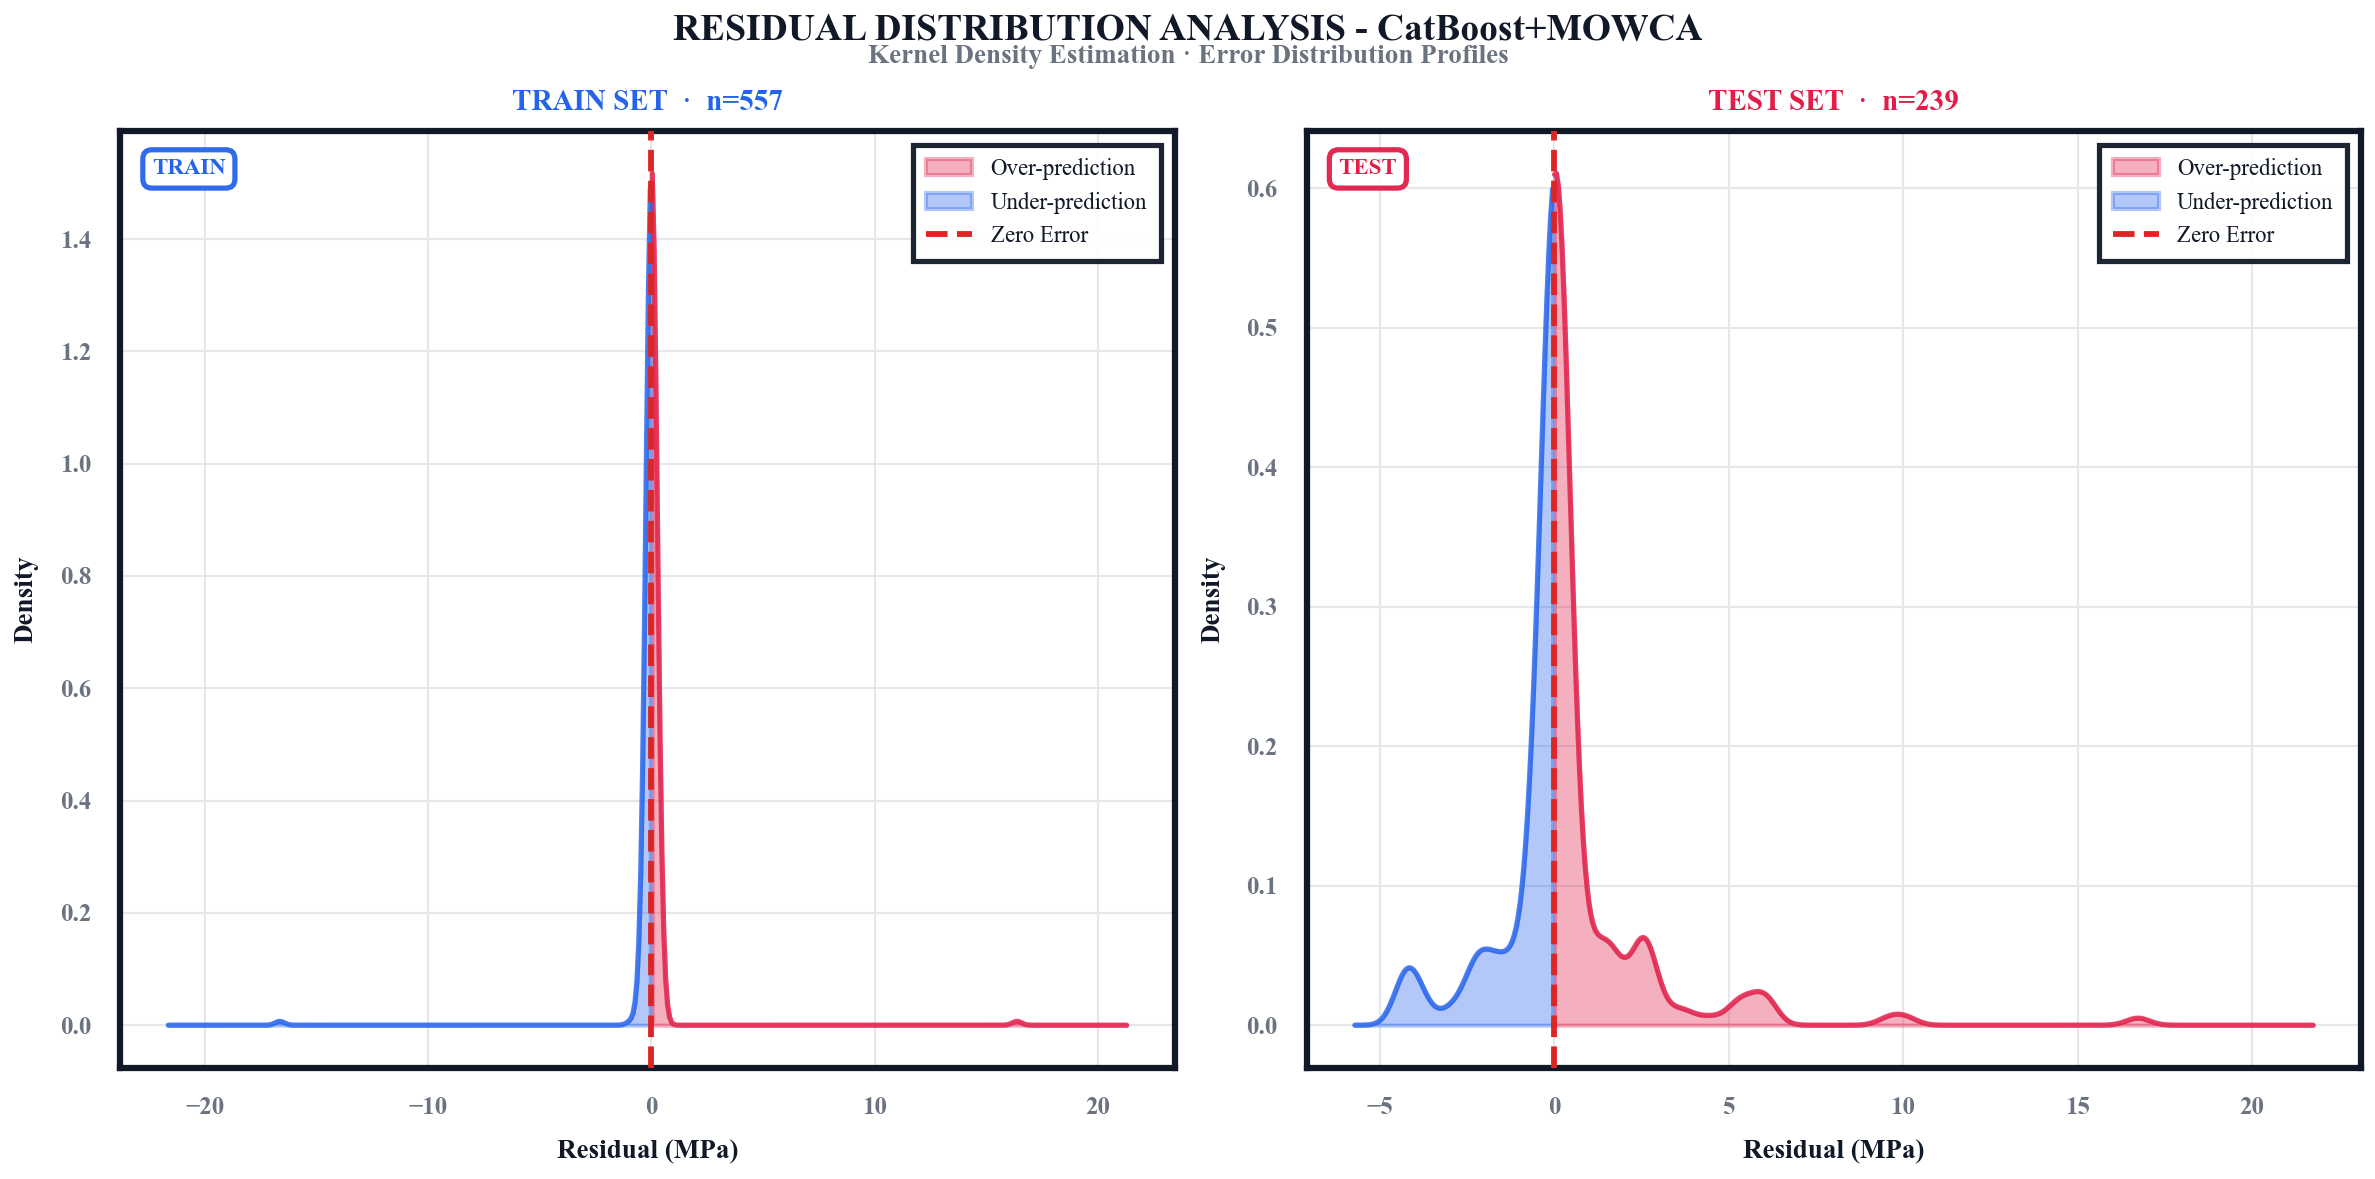

▶ Plot A — Simple Scatter (Train)...
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotA_scatter_train_simple.png


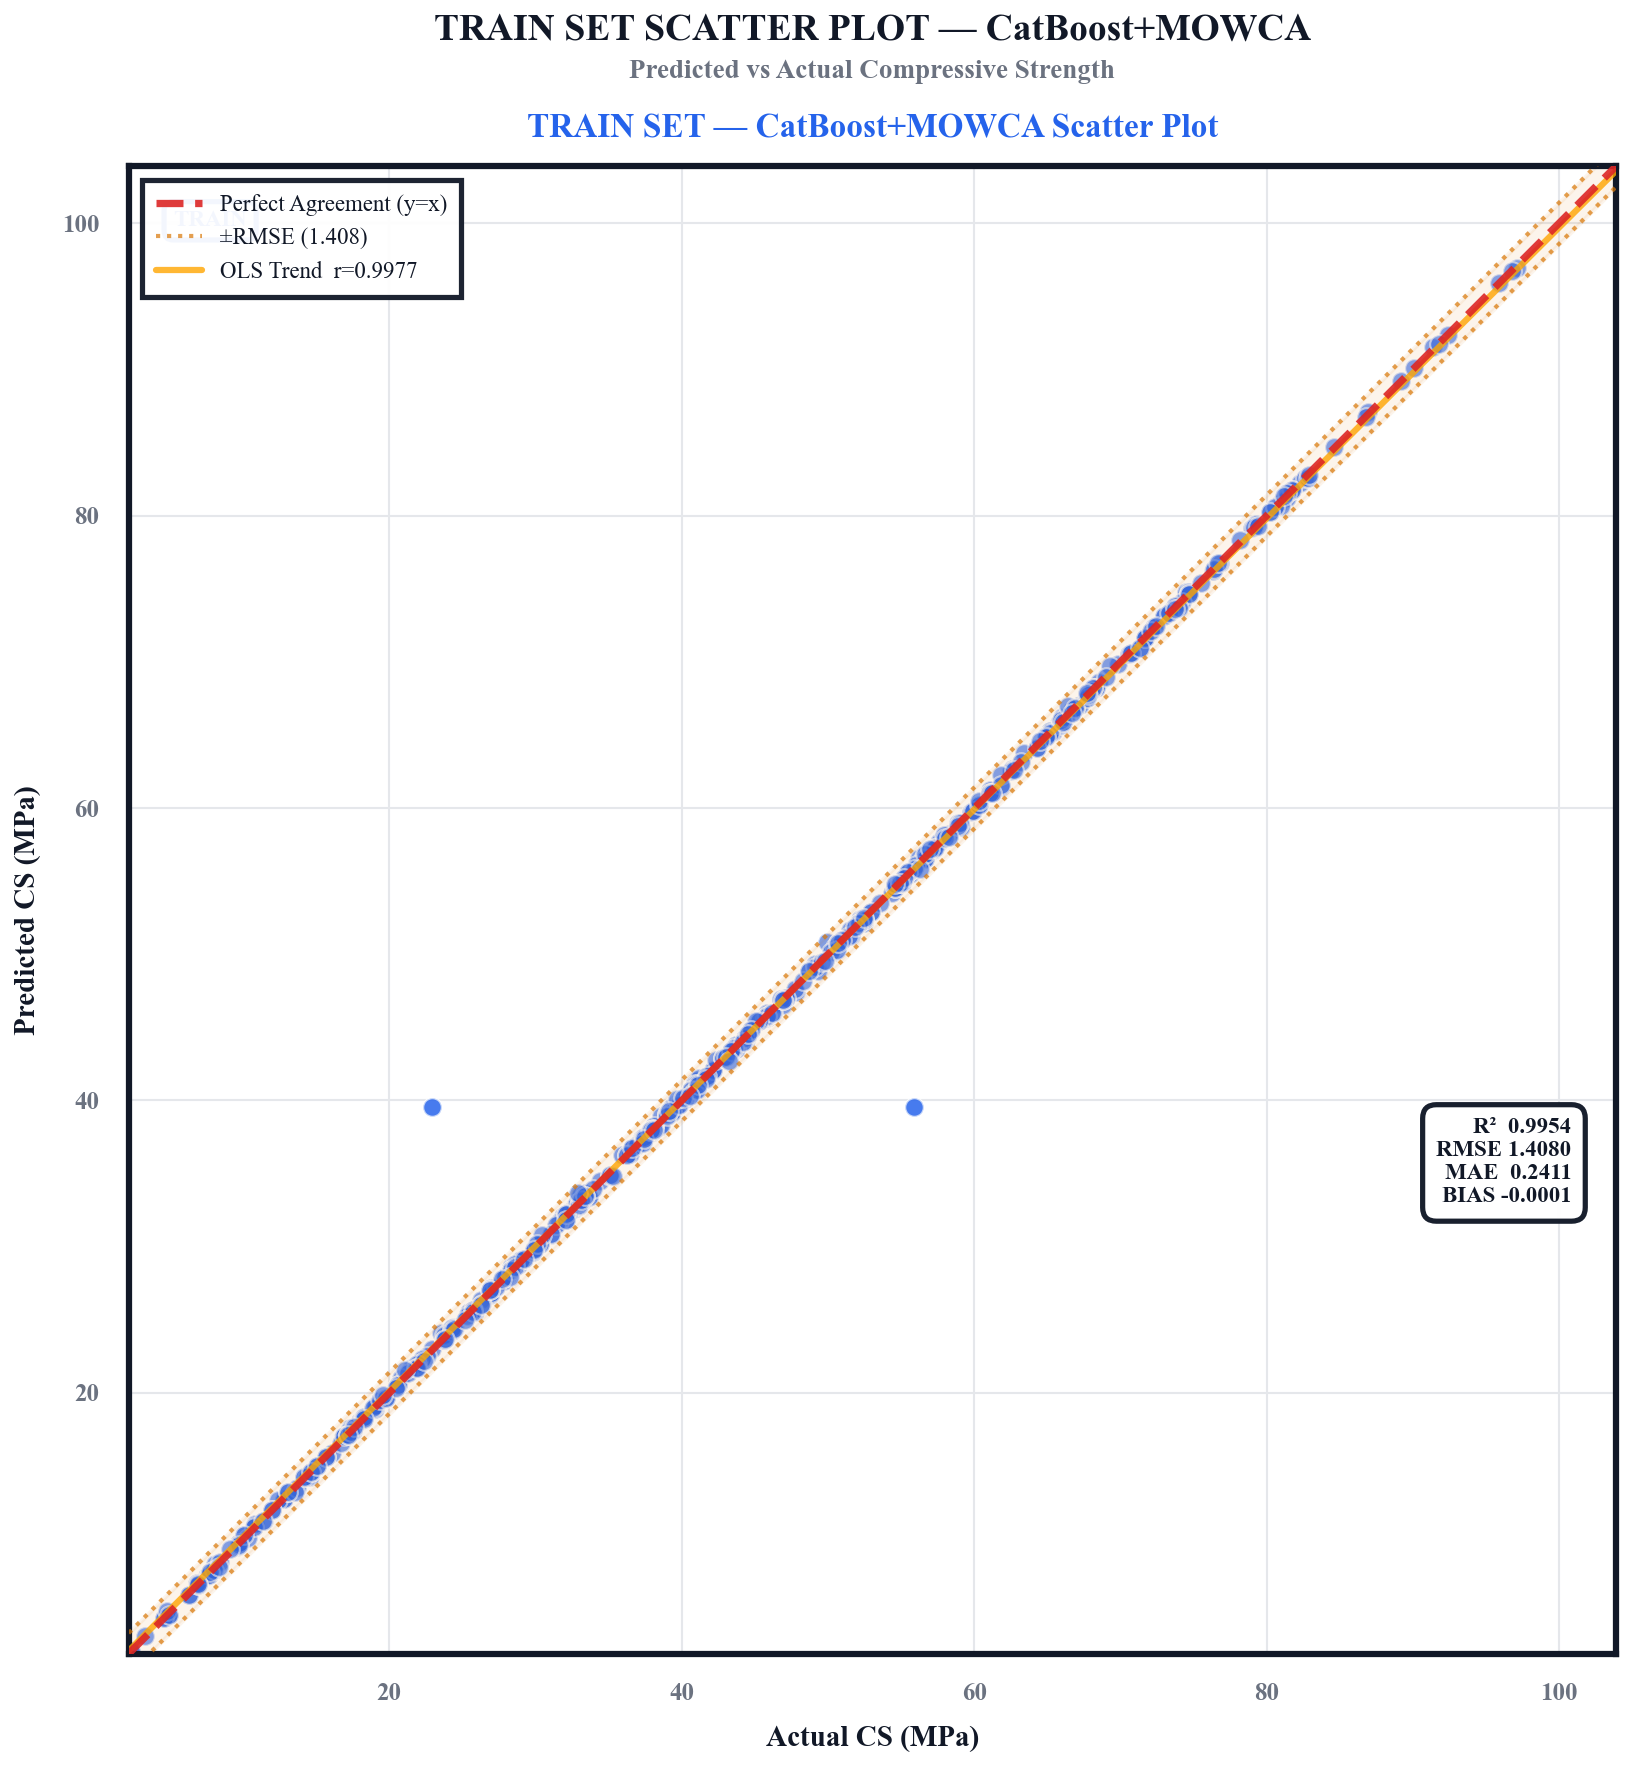

▶ Plot B — Simple Scatter (Test)...
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotB_scatter_test_simple.png


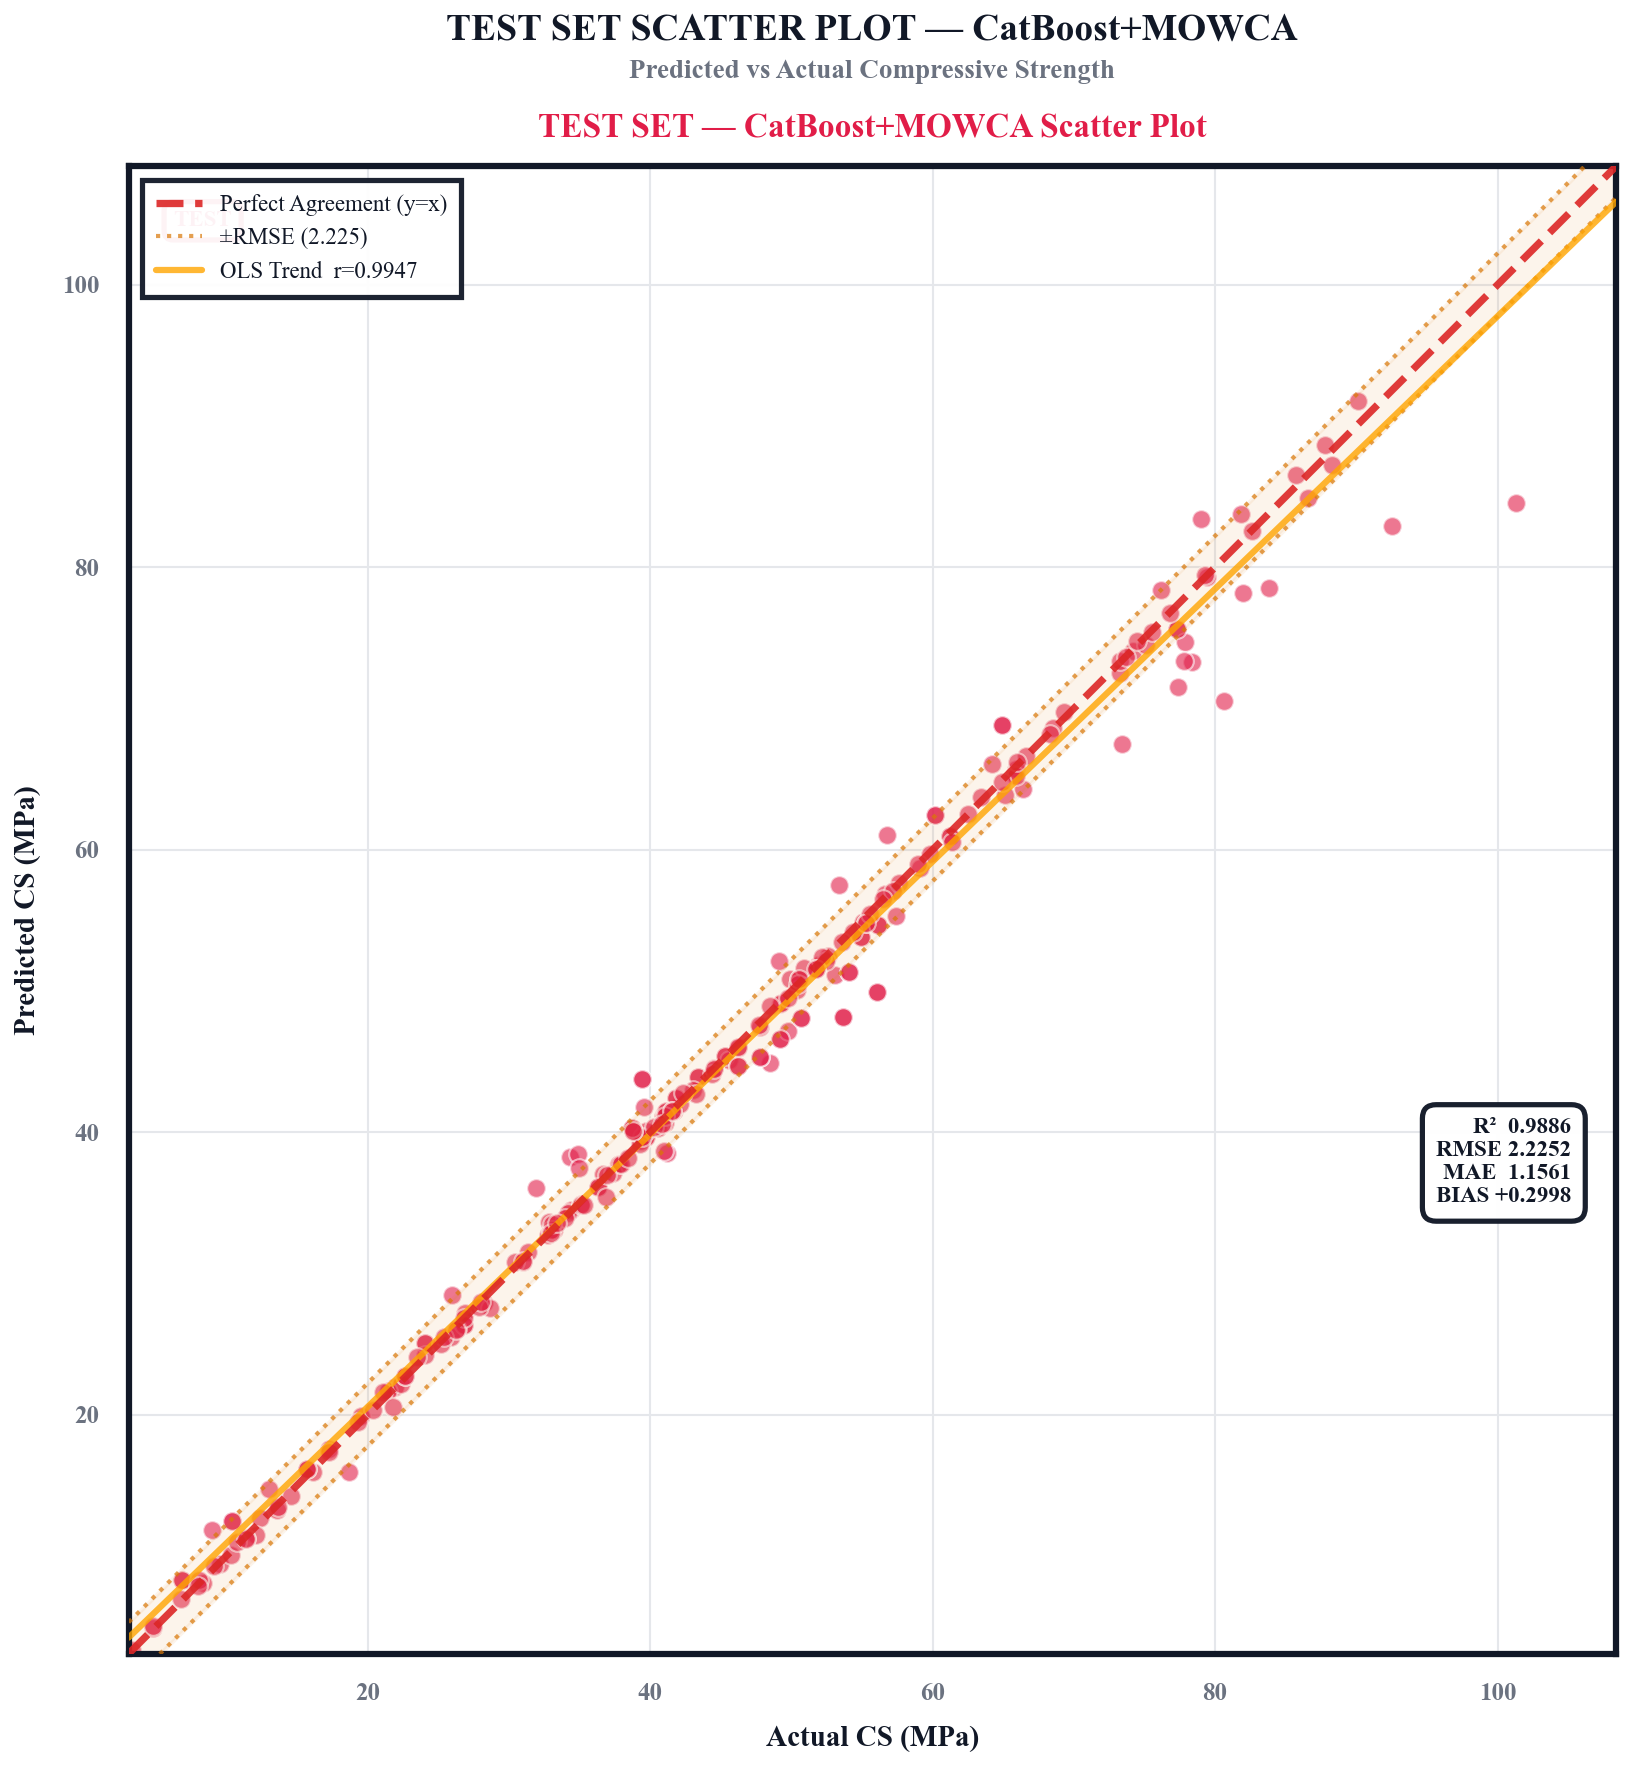


▶ Plot C — SHAP Feature Importance...
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotC_shap_importance.png


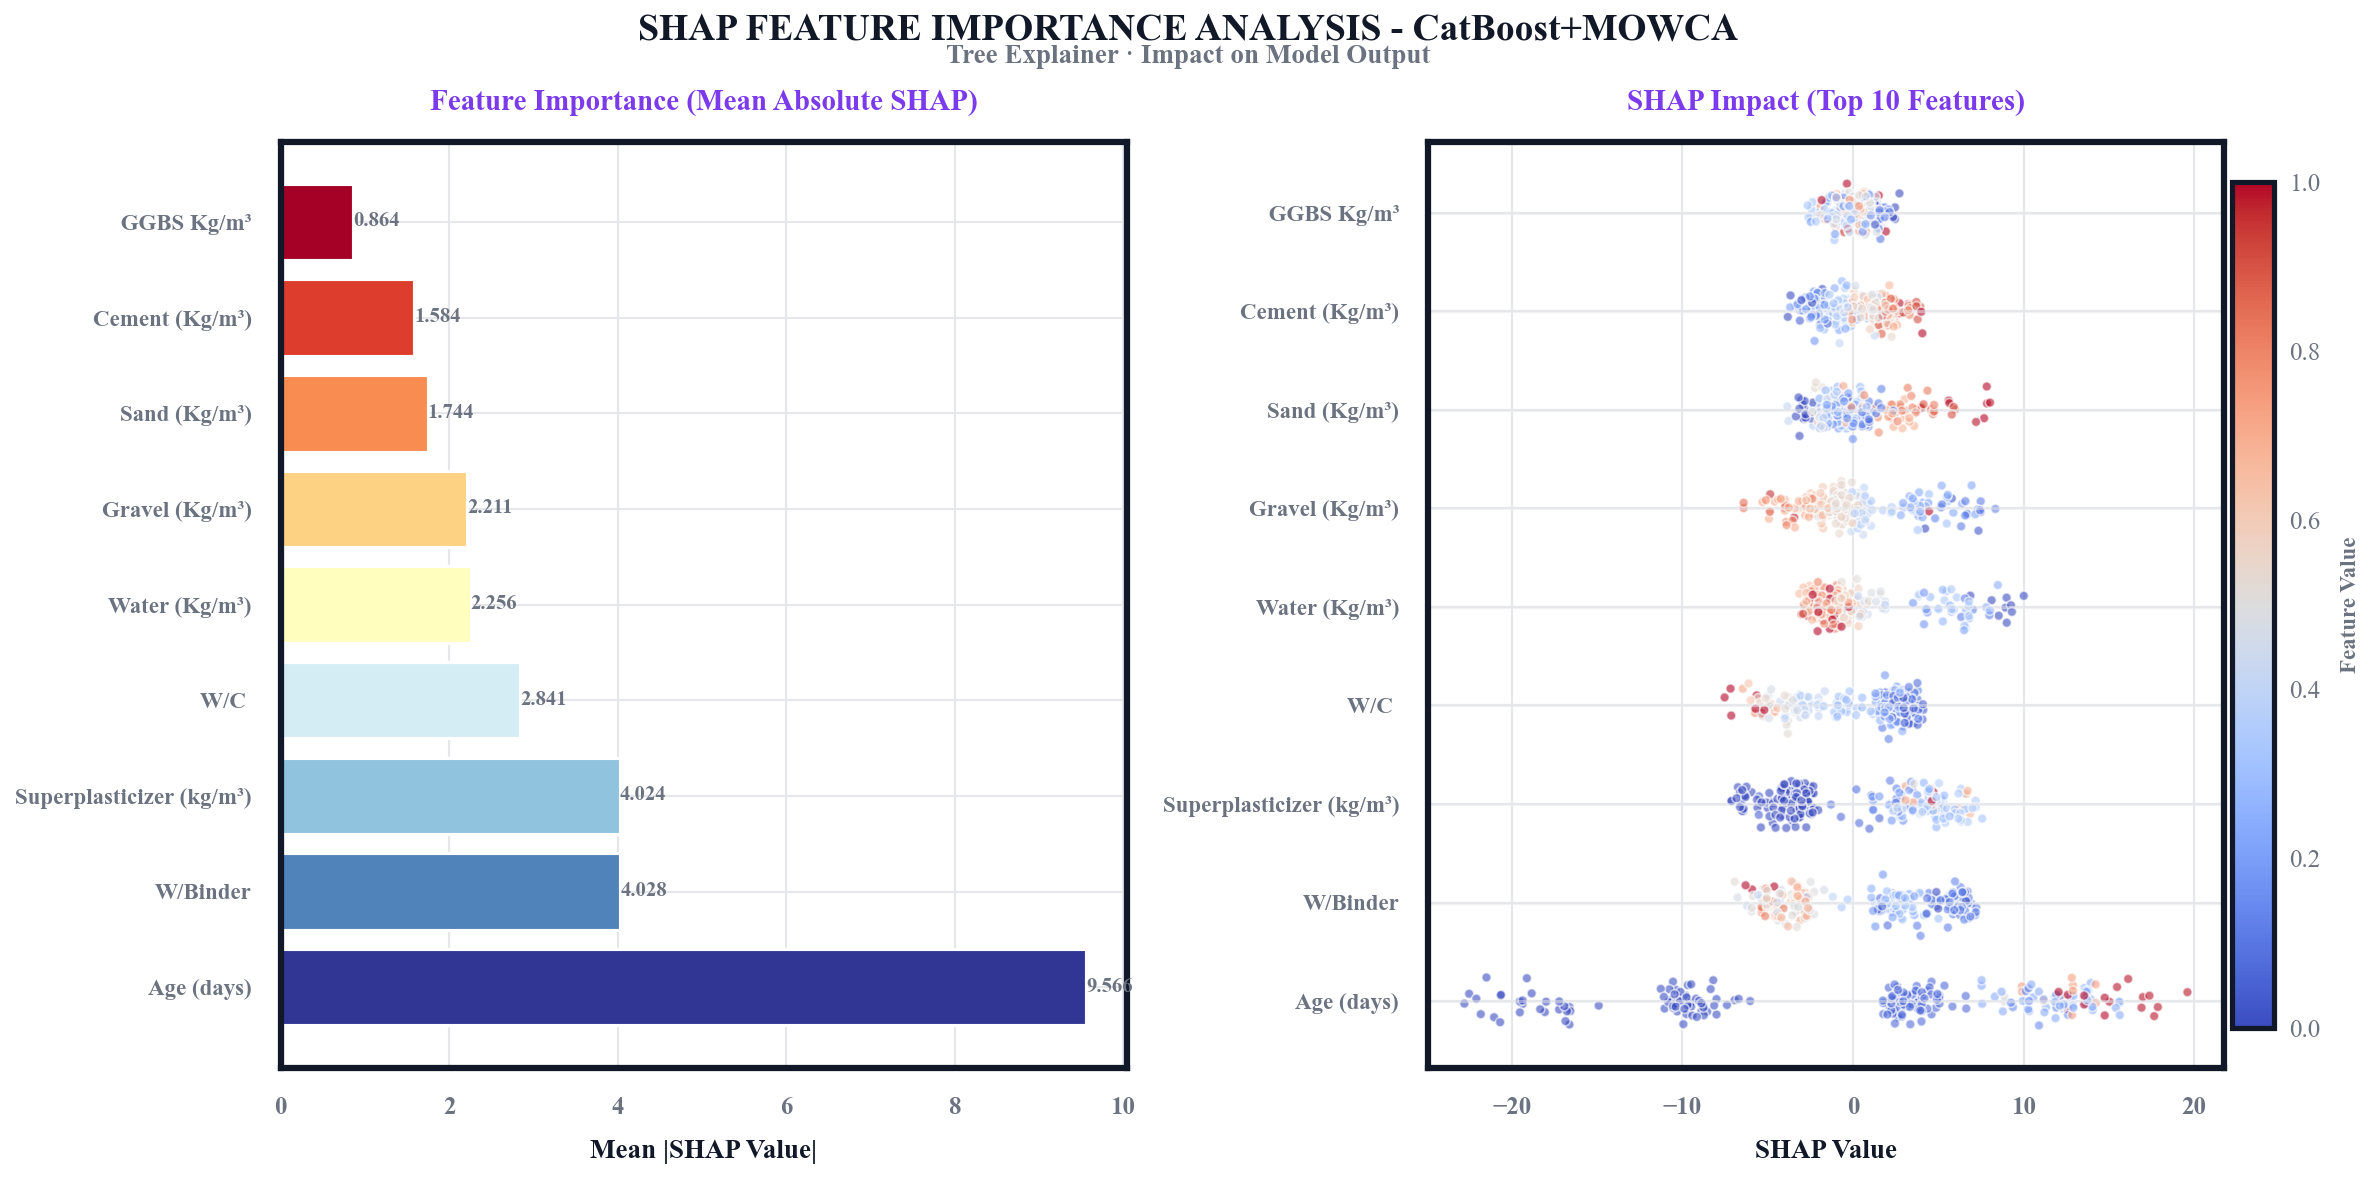


▶ Plot D — Learning Curves...

Computing learning curves...
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotD_learning_curves.png


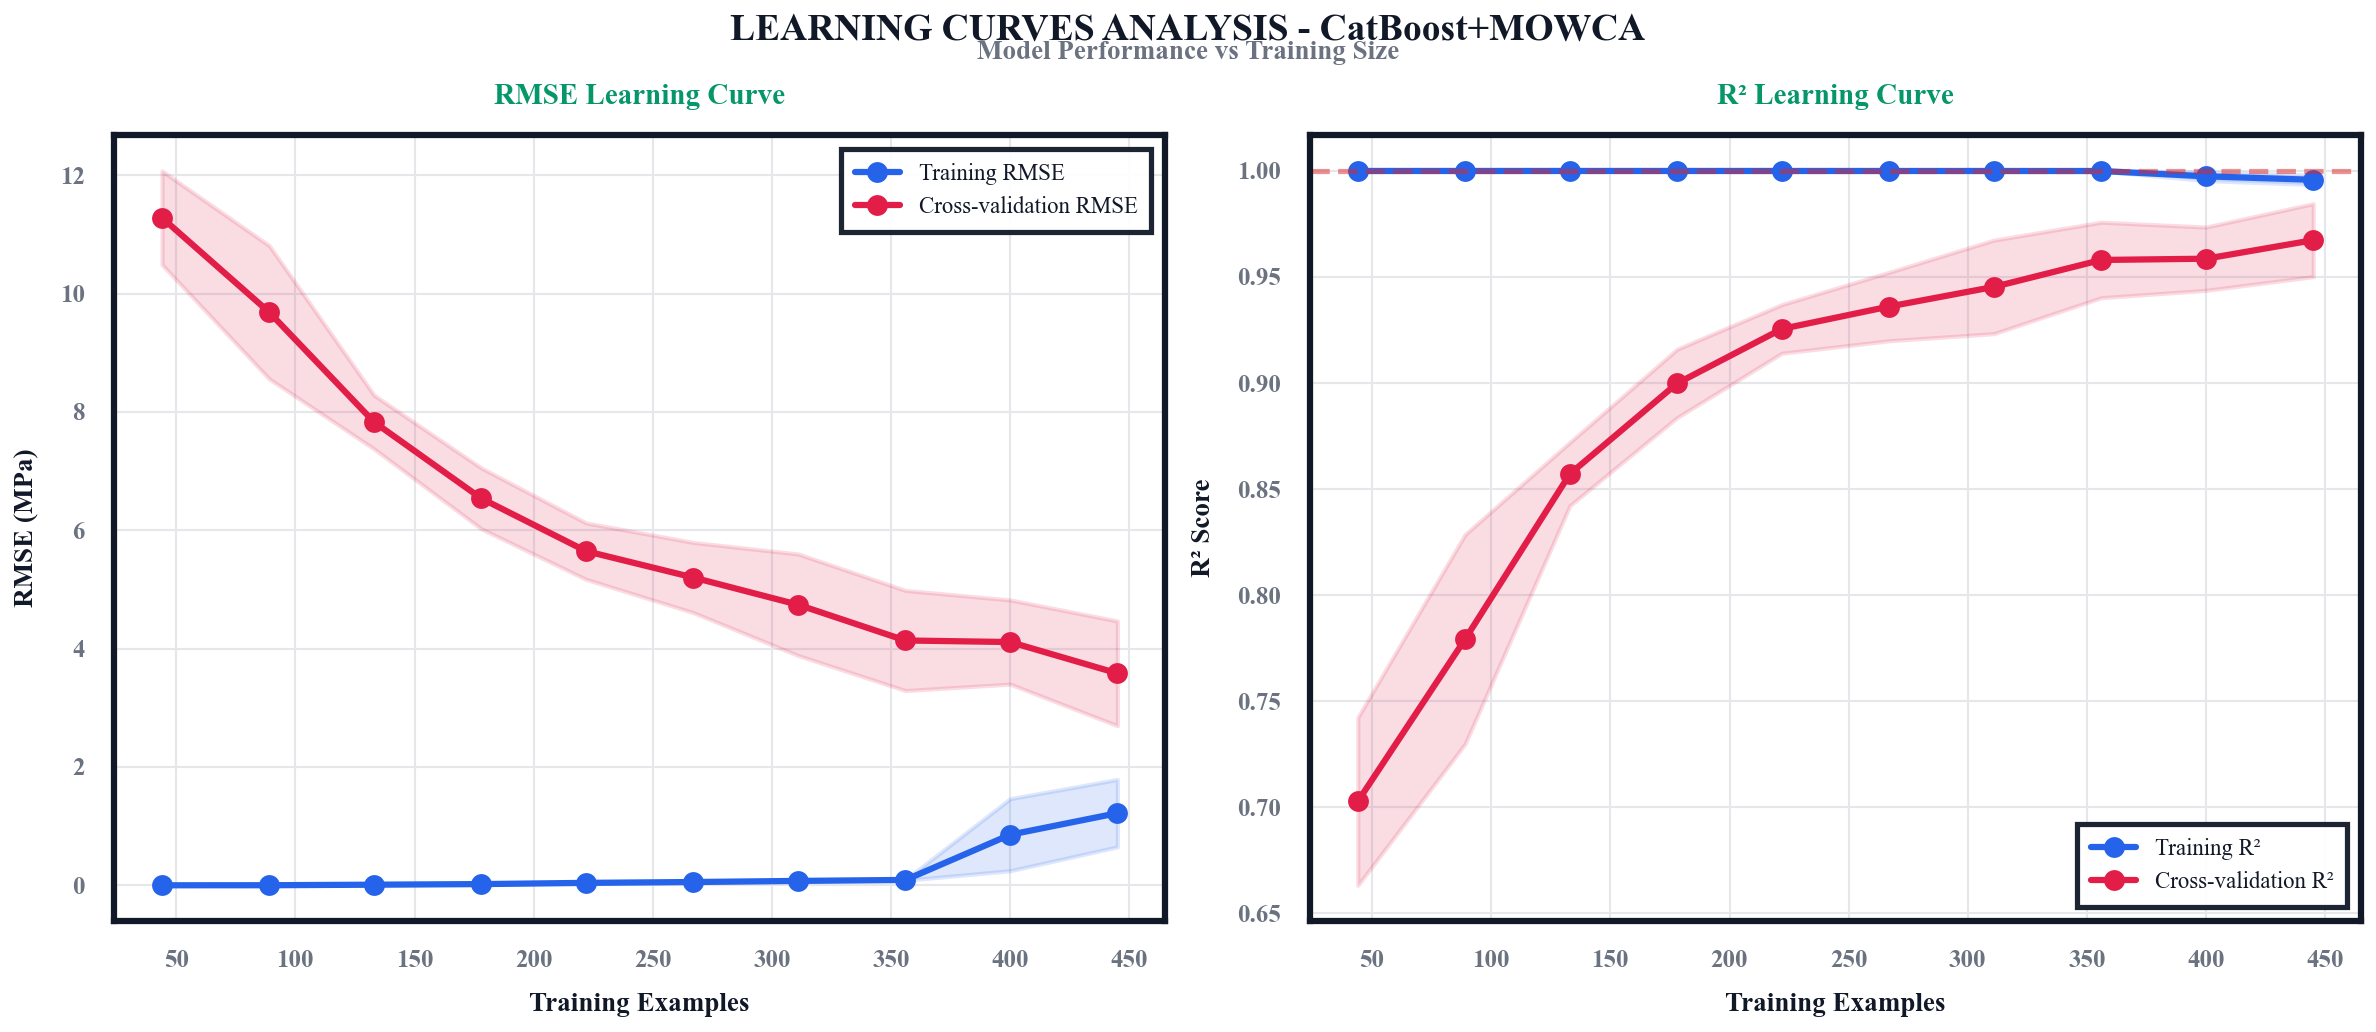


▶ Plot E — Prediction Intervals...

Computing prediction intervals...

COMPUTING PREDICTION INTERVALS
Prediction intervals computed (95.0% confidence)
Average interval width: 4.0674 MPa
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotE_prediction_intervals.png


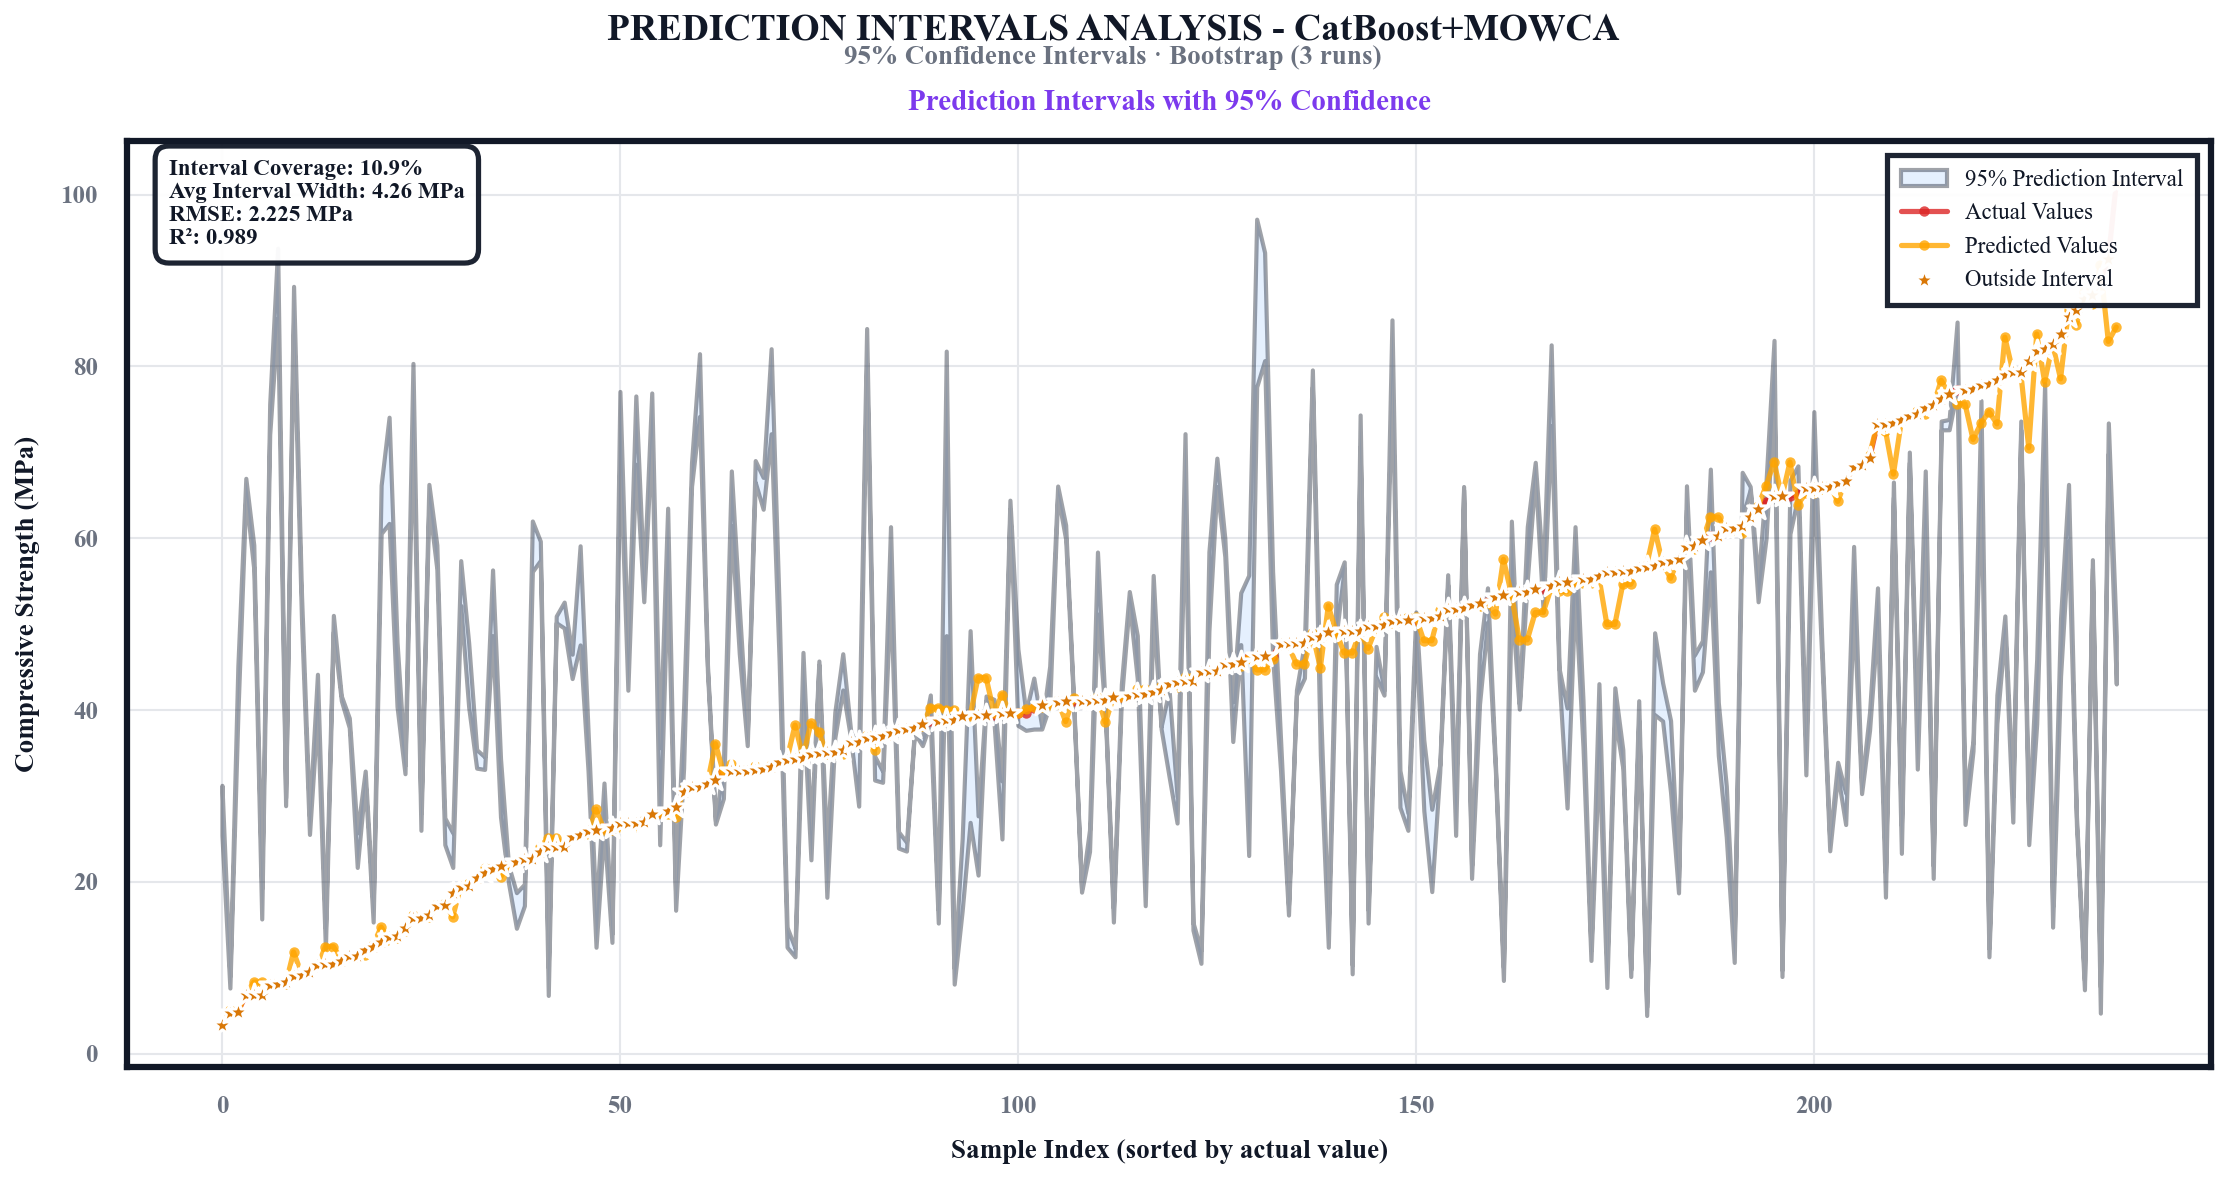


▶ Plot F — CV Stability...
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotF_cv_stability.png


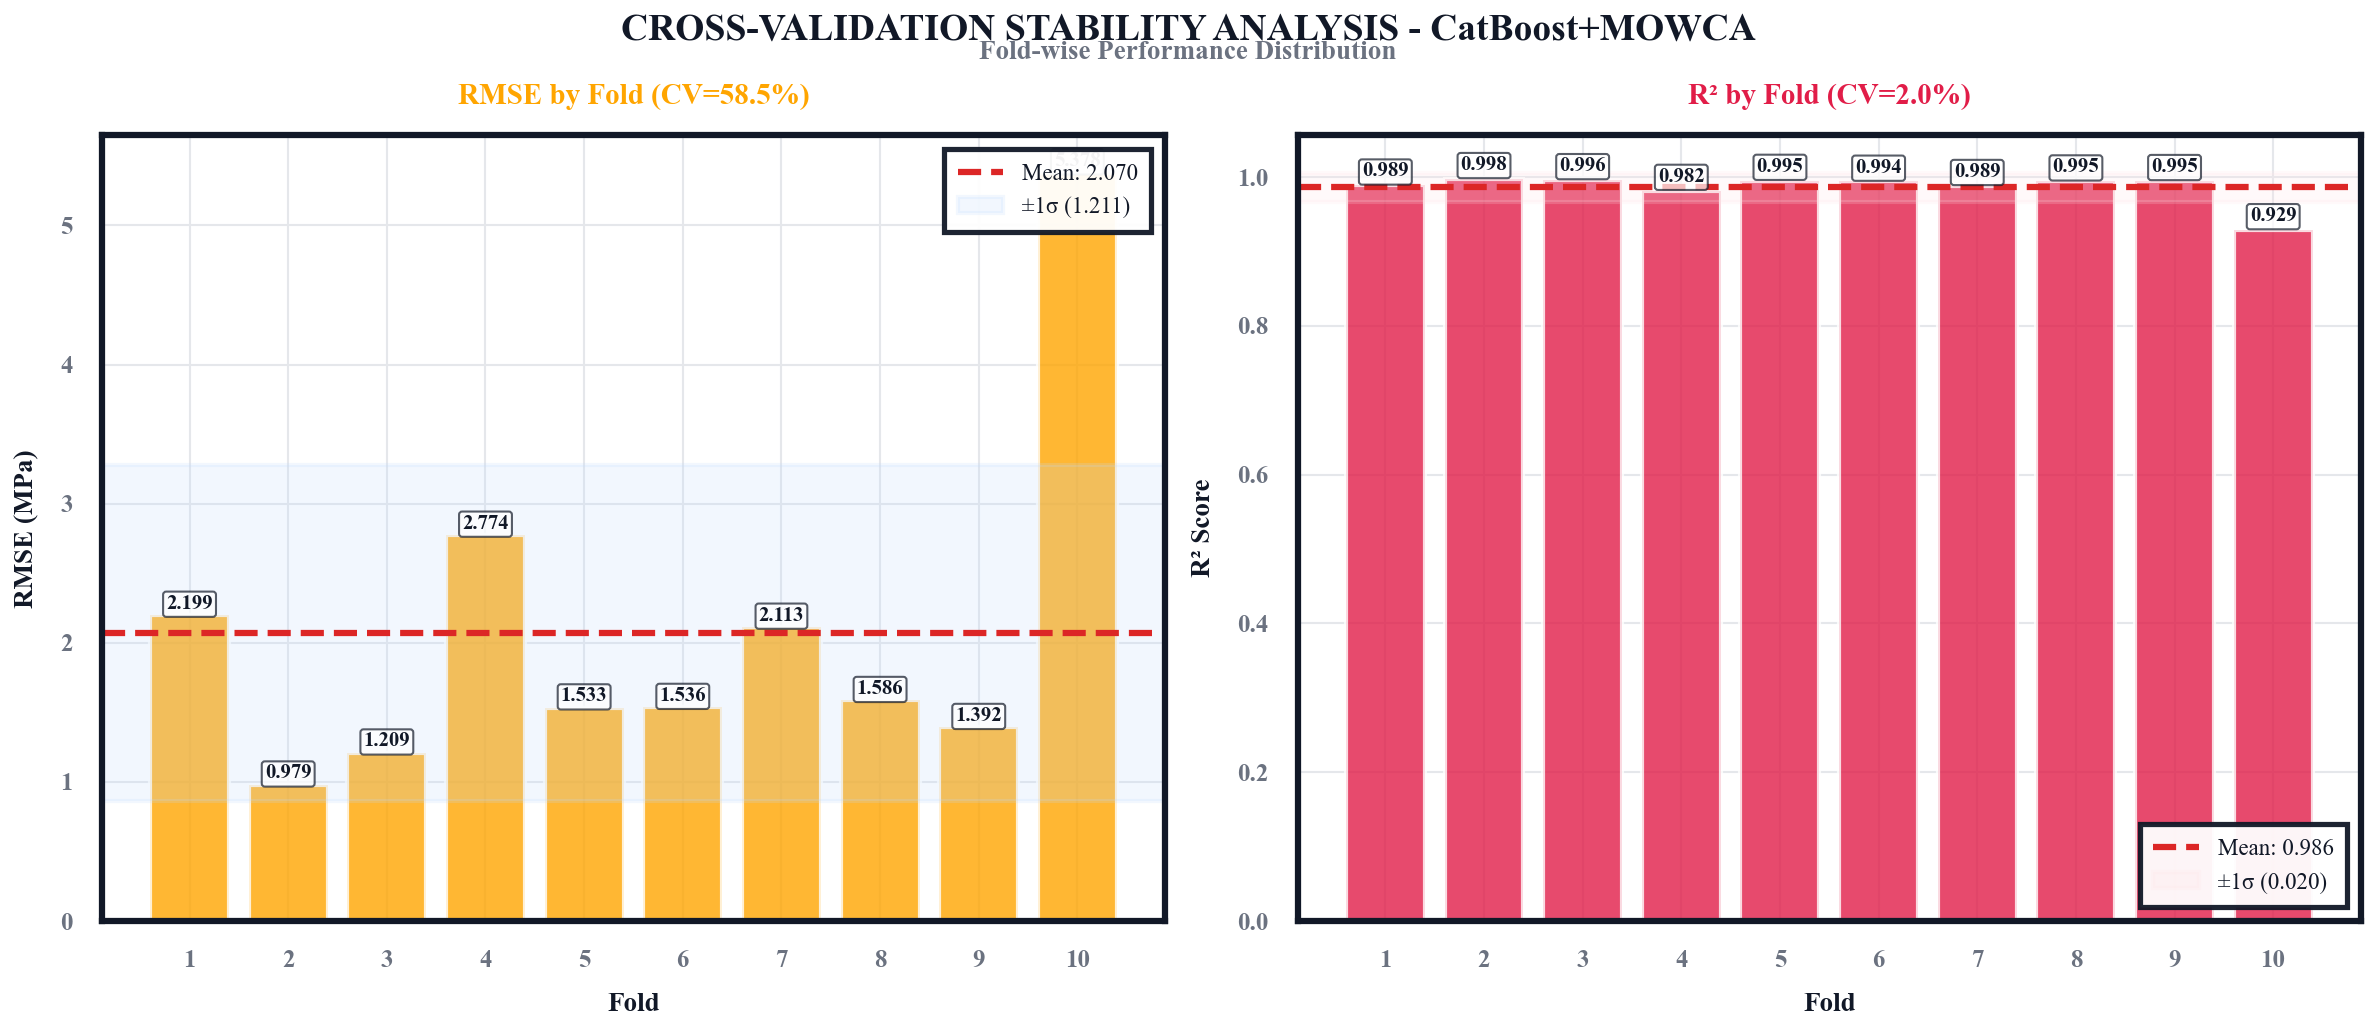


▶ Plot G — Error Metrics Dashboard...
✓ Saved: D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA\plotG_error_dashboard.png


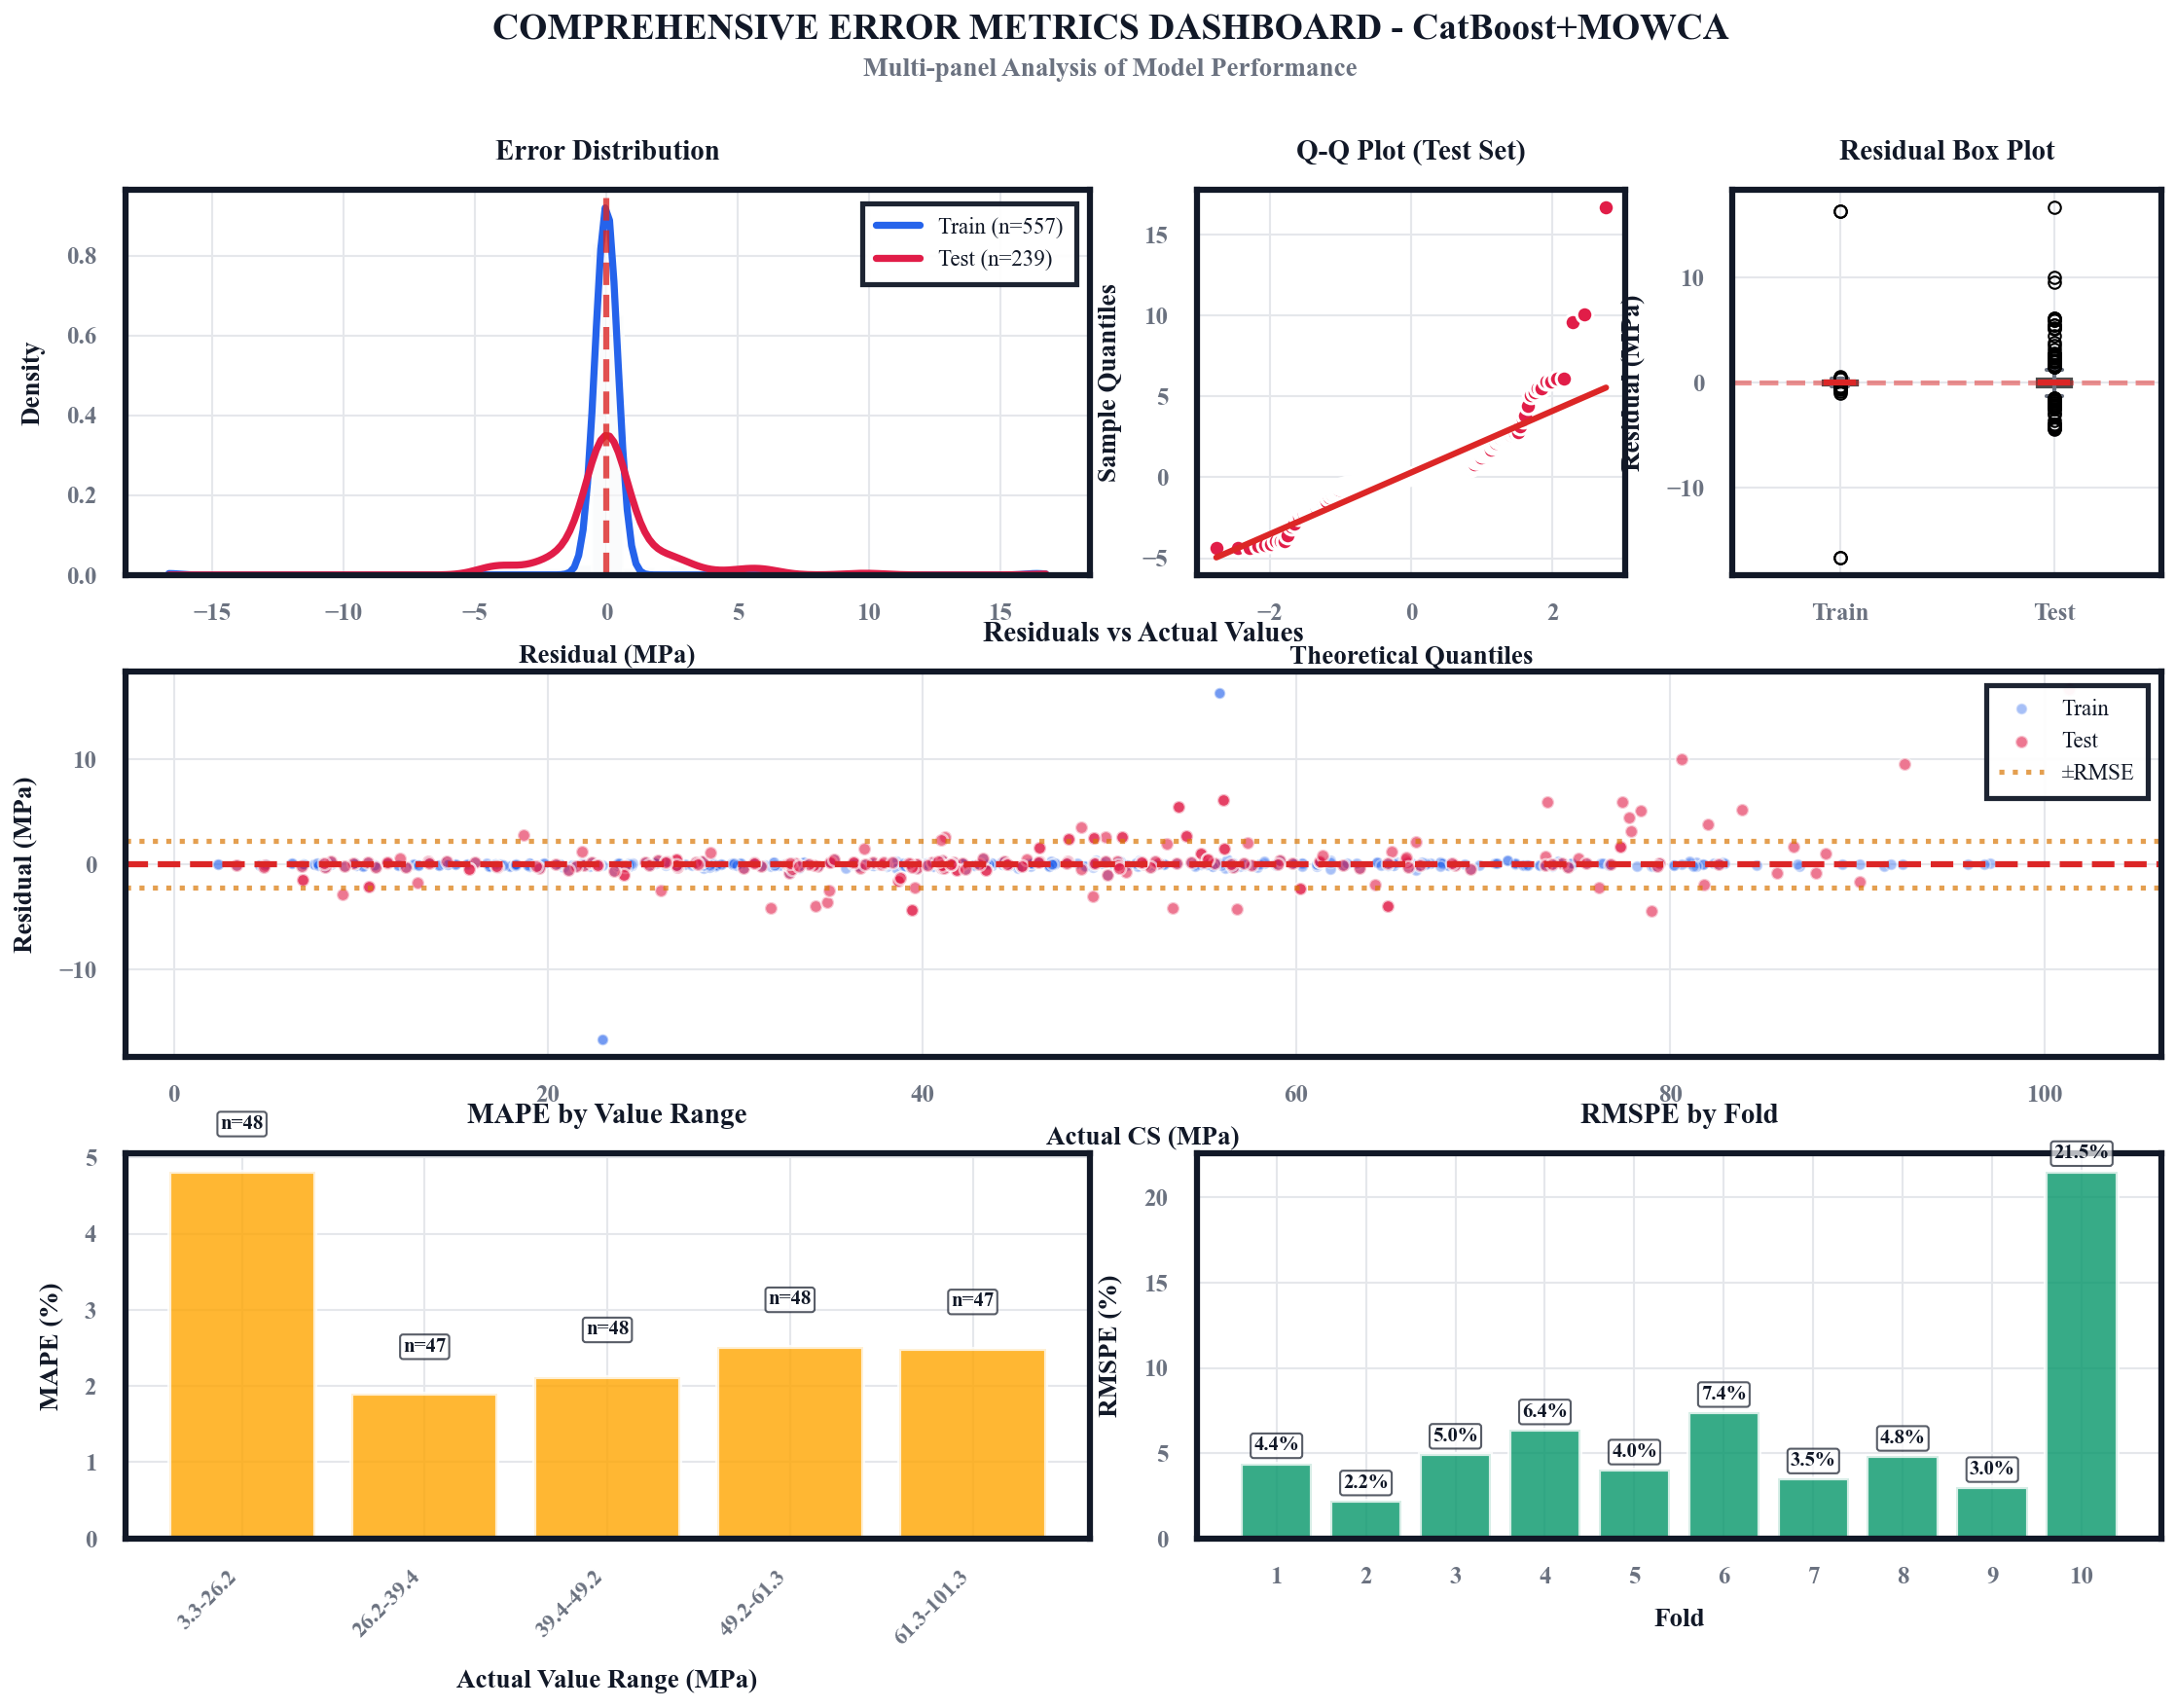


══════════════════════════════════════════════════════════════
                ✓ ALL ENHANCED PLOTS GENERATED                
══════════════════════════════════════════════════════════════

                         FINAL SUMMARY - CATBOOST+MOWCA ANALYSIS

CATBOOST+MOWCA OPTIMIZATION SUMMARY (10-FOLD CV):
--------------------------------------------------
  Average RMSE: 1.9348 ± 1.1196 MPa
  Average R²: 0.9881 ± 0.0167
  Average MAE: 1.1222 ± 0.4478 MPa
  Average MAPE: 3.40 ± 1.74%
  Average Iterations: 332 ± 52
  Computation Time: 404.38 seconds

BEST PARAMETERS FOUND:
--------------------------------------------------
  Depth: 8
  Learning Rate: 0.1162
  Iterations: 389
  L2 Leaf Reg: 1.0000
  Border Count: 200
  Subsample: 0.7249
  Colsample: 0.8386
  Min Data Leaf: 1

FINAL TEST SET PERFORMANCE:
--------------------------------------------------
  RMSE: 2.2252 MPa
  R²: 0.9886
  MAE: 1.1561 MPa
  MAPE: 2.83%
  RMSPE: 5.16%
  Bias: +0.2998 MPa

                              ANALYSI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.utils import shuffle
from scipy.stats import friedmanchisquare, wilcoxon, norm, probplot, gaussian_kde, ttest_ind, pearsonr
from catboost import CatBoostRegressor, Pool
from math import sqrt
import warnings
from tabulate import tabulate
import time
import os
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import matplotlib.patheffects as pe
import shap
from sklearn.preprocessing import StandardScaler
import tempfile
warnings.filterwarnings('ignore')

# =============================================================================
# SECTION 1: CONFIGURATION AND STYLE SETTINGS
# =============================================================================

# Set Times New Roman as default font
plt.rcParams['font.family'] = 'Times New Roman'

# Set global style for all plots - WHITE BACKGROUND
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
sns.set_style("whitegrid")

# EDITORIAL WHITE PALETTE WITH THICKER BORDERS - ALL WHITE BACKGROUND
PALETTE = {
    'bg':         '#FFFFFF',          # Pure white background
    'surface':    '#FFFFFF',          # Pure white surface
    'surface2':   '#F8F9FA',          # Very light gray for subtle contrast
    'border':     '#111827',          # Darker border for better visibility
    'border_light': '#D1D5DB',
    'train_core': '#2563EB',
    'train_glow': '#BFDBFE',
    'test_core':  '#E11D48',
    'test_glow':  '#FFE4E6',
    'accent':     '#7C3AED',
    'accent2':    '#059669',
    'perfect':    '#DC2626',
    'grid':       '#E5E7EB',          # Light gray grid
    'text_hi':    '#111827',
    'text_mid':   '#6B7280',
    'text_low':   '#9CA3AF',
    'warning':    '#D97706',
    'arrow_over': '#E11D48',
    'arrow_under':'#2563EB',
    'arrow_out':  '#7C3AED',
    'catboost':   '#FFA500',
    'shap':       '#7C3AED',
    'learning':   '#059669',
}

# Custom colormaps
CMAP_TRAIN = LinearSegmentedColormap.from_list(
    'train', ['#FFFFFF', '#DBEAFE', '#93C5FD', '#3B82F6', '#1D4ED8'], N=256
)
CMAP_TEST = LinearSegmentedColormap.from_list(
    'test', ['#FFFFFF', '#FFE4E6', '#FCA5A5', '#F87171', '#B91C1C'], N=256
)
CMAP_RESIDUAL = LinearSegmentedColormap.from_list(
    'residual', ['#E11D48', '#F9FAFB', '#2563EB'], N=256
)
CMAP_SHAP = LinearSegmentedColormap.from_list(
    'shap', ['#2563EB', '#FFFFFF', '#E11D48'], N=256
)

# Global style for cinematic plots with THICKER BORDERS and WHITE background
# Only use valid matplotlib rc parameters
CINEMATIC_RC_PARAMS = {
    'font.family':       'Times New Roman',
    'font.size':         12,
    'figure.facecolor':  '#FFFFFF',      # White figure background
    'axes.facecolor':    '#FFFFFF',      # White axes background
    'axes.edgecolor':    PALETTE['border'],
    'axes.linewidth':    3.0,            # Thicker borders
    'axes.labelcolor':   PALETTE['text_hi'],
    'axes.labelsize':    14,
    'axes.titlesize':    16,
    'axes.titlecolor':   PALETTE['text_hi'],
    'axes.labelpad':     10,
    'axes.titlepad':     15,
    'xtick.color':       PALETTE['text_mid'],
    'ytick.color':       PALETTE['text_mid'],
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'legend.fontsize':   12,
    'legend.facecolor':  '#FFFFFF',      # White legend background
    'legend.edgecolor':  PALETTE['border'],
    'legend.framealpha': 0.95,
    'legend.fancybox':   False,
    'legend.frameon':    True,
    'legend.borderpad':  0.6,
    'legend.borderaxespad': 0.6,
    'grid.color':        PALETTE['grid'],
    'grid.linewidth':    1.0,
    'grid.alpha':        1.0,
    'figure.dpi':        150,
    'savefig.dpi':       500,
    'savefig.facecolor': '#FFFFFF',      # White save background
    'savefig.edgecolor': '#FFFFFF',
    'savefig.bbox':      'tight',
    'text.color':        PALETTE['text_hi'],
    'lines.linewidth':   3.0,
    'patch.linewidth':   2.0,
    'patch.edgecolor':   PALETTE['border'],
}

# =============================================================================
# SECTION 2: UTILITY FUNCTIONS FOR PLOTTING
# =============================================================================

def apply_thick_borders(ax, linewidth=3.0):
    """Apply thick borders to axes"""
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)
        spine.set_color(PALETTE['border'])
    ax.tick_params(width=2.0, length=7)
    return ax

def style_ax(ax, grid=True, thick_borders=True):
    """Style axes with publication-ready formatting and thick borders"""
    ax.set_facecolor('#FFFFFF')  # White background
    
    if thick_borders:
        for spine in ax.spines.values():
            spine.set_color(PALETTE['border'])
            spine.set_linewidth(3.0)
    else:
        for spine in ax.spines.values():
            spine.set_color(PALETTE['border_light'])
            spine.set_linewidth(1.5)
    
    if grid:
        ax.grid(True, color=PALETTE['grid'], linewidth=1.0, alpha=1.0)
        ax.set_axisbelow(True)
    
    ax.tick_params(colors=PALETTE['text_mid'], length=7, width=2.0)
    # Set tick labels to bold
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    return ax

def add_metric_badge(ax, metrics, x=0.97, y=0.05, align='right'):
    """Add metrics badge to plot with thick border"""
    txt = (f"R²  {metrics['r2']:.4f}\n"
           f"RMSE {metrics['rmse']:.4f}\n"
           f"MAE  {metrics['mae']:.4f}\n"
           f"BIAS {metrics['bias']:+.4f}")
    
    bbox_props = dict(
        boxstyle='round,pad=0.6',
        facecolor='#FFFFFF',  # White background
        edgecolor=PALETTE['border'],
        alpha=0.97, 
        linewidth=2.5
    )
    
    ax.text(x, y, txt, transform=ax.transAxes,
            fontsize=11, color=PALETTE['text_hi'], fontweight='bold',
            ha=align, va='bottom', bbox=bbox_props)

def fig_title(fig, text, subtitle=""):
    """Add figure title with styling"""
    fig.text(0.5, 0.98, text, ha='center', va='top',
             fontsize=18, color=PALETTE['text_hi'], fontweight='bold',
             transform=fig.transFigure)
    if subtitle:
        fig.text(0.5, 0.955, subtitle, ha='center', va='top',
                 fontsize=13, color=PALETTE['text_mid'], fontweight='bold',
                 transform=fig.transFigure)

def add_corner_label(ax, text, color):
    """Add corner label with thick border"""
    bbox_props = dict(
        boxstyle='round,pad=0.4',
        facecolor='#FFFFFF',  # White background
        edgecolor=color,
        alpha=0.95, 
        linewidth=2.5
    )
    
    ax.text(0.03, 0.97, text, transform=ax.transAxes,
            fontsize=11, color=color, va='top', fontweight='bold',
            bbox=bbox_props)

# =============================================================================
# SECTION 3: MOWCA-CATBOOST OPTIMIZER CLASS
# =============================================================================

class MOWCACatBoostOptimizer:
    """MOWCA (Multi-Objective Water Cycle Algorithm) optimization for CatBoost with cross-validation"""
    
    def __init__(self, X, y, n_streams=6, max_iter=20, n_cv_folds=10,
                 n_runs=3, random_state=42, output_dir='CatBoost_Results'):
        self.X = X
        self.y = y
        self.n_streams = n_streams
        self.max_iter = max_iter
        self.n_cv_folds = n_cv_folds
        self.n_runs = n_runs
        self.random_state = random_state
        self.all_runs_results = []
        self.computation_time = 0
        self.best_model = None
        self.best_params = None
        self.best_cost = float('inf')
        self.training_results = None
        self.testing_results = None
        self.scaler = StandardScaler()
        self.all_fold_metrics = []
        self.cv_stability_scores = []
        self.shap_values = None
        self.feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X.shape[1])]
        
        # Create output directory with error handling
        self.output_dir = output_dir
        try:
            if not os.path.exists(output_dir):
                os.makedirs(output_dir)
                print(f"Created output directory: {output_dir}")
        except PermissionError:
            # Use a directory with write permissions
            temp_dir = tempfile.mkdtemp(prefix='catboost_results_')
            self.output_dir = temp_dir
            print(f"⚠️ Permission denied for {output_dir}. Using temporary directory: {temp_dir}")
        except Exception as e:
            # Fallback to current directory
            self.output_dir = os.getcwd()
            print(f"⚠️ Error creating directory. Using current directory: {self.output_dir}")
        
        # Parameter bounds for CatBoost
        self.bounds = np.array([
            (3, 8),           # depth
            (0.01, 0.15),     # learning_rate
            (100, 400),       # iterations
            (1, 10),          # l2_leaf_reg
            (32, 255),        # border_count
            (0.6, 0.9),       # subsample
            (0.6, 0.9),       # colsample_bylevel
            (1, 10)           # min_data_in_leaf
        ])
        
        # MOWCA specific parameters
        self.d_max = 1e-6  # Maximum distance for termination
        self.n_sea = 1      # Number of seas (best solutions)
        self.n_rivers = 3   # Number of rivers (second best solutions)
        self.n_streams_total = n_streams  # Total number of streams
        
        # Calculate total model fits
        self.total_fits = n_runs * n_cv_folds * n_streams * max_iter
        
        print(f"\nMOWCA-CatBoost Optimizer initialized:")
        print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
        print(f"Number of runs: {n_runs}")
        print(f"10-fold Cross-Validation")
        print(f"MOWCA: Streams={n_streams}, Iterations={max_iter}")
        print(f"Total model fits: {self.total_fits:,}")
        print(f"Output directory: {self.output_dir}")
    
    # -------------------------------------------------------------------------
    # MOWCA Optimization Methods
    # -------------------------------------------------------------------------
    
    def objective_function(self, params, X_train, y_train, X_val, y_val):
        """Objective function for MOWCA optimization with CatBoost"""
        try:
            depth, learning_rate, iterations, l2_leaf_reg, border_count, \
            subsample, colsample_bylevel, min_data_in_leaf = params
            
            # Convert to appropriate types
            depth = int(depth)
            iterations = int(iterations)
            border_count = int(border_count)
            min_data_in_leaf = int(min_data_in_leaf)
            
            model = CatBoostRegressor(
                depth=depth,
                learning_rate=learning_rate,
                iterations=iterations,
                l2_leaf_reg=l2_leaf_reg,
                border_count=border_count,
                subsample=subsample,
                colsample_bylevel=colsample_bylevel,
                min_data_in_leaf=min_data_in_leaf,
                random_seed=self.random_state,
                verbose=0,
                early_stopping_rounds=15,
                thread_count=-1
            )
            
            model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
            y_pred = model.predict(X_val)
            
            # Use RMSE as objective
            rmse = sqrt(mean_squared_error(y_val, y_pred))
            
            return rmse
            
        except Exception as e:
            print(f"Error in objective function: {e}")
            return float('inf')
    
    def run_mowca_optimization(self, X_train, y_train, X_val, y_val):
        """Run MOWCA optimization for hyperparameter tuning"""
        
        # Initialize population
        n_params = len(self.bounds)
        population = np.zeros((self.n_streams_total, n_params))
        
        for i in range(self.n_streams_total):
            for j in range(n_params):
                population[i, j] = np.random.uniform(self.bounds[j, 0], self.bounds[j, 1])
        
        # Evaluate initial population
        costs = np.zeros(self.n_streams_total)
        for i in range(self.n_streams_total):
            costs[i] = self.objective_function(population[i], X_train, y_train, X_val, y_val)
        
        # Sort population by cost
        sorted_indices = np.argsort(costs)
        population = population[sorted_indices]
        costs = costs[sorted_indices]
        
        # Assign sea, rivers, and streams
        sea = population[0].copy()
        sea_cost = costs[0]
        rivers = population[1:self.n_rivers+1].copy()
        rivers_costs = costs[1:self.n_rivers+1]
        streams = population[self.n_rivers+1:].copy()
        streams_costs = costs[self.n_rivers+1:]
        
        # MOWCA main loop
        best_cost_history = [sea_cost]
        
        for iteration in range(self.max_iter):
            # Calculate flow intensity
            total_cost = np.sum(rivers_costs) + sea_cost
            if total_cost == 0:
                total_cost = 1e-10
            
            # Calculate probabilities for rivers
            probs = np.zeros(self.n_rivers)
            for i in range(self.n_rivers):
                probs[i] = rivers_costs[i] / total_cost
            
            # Generate new streams
            new_streams = []
            new_streams_costs = []
            
            for i in range(len(streams)):
                # Choose river or sea
                rand = np.random.random()
                if rand < np.min(probs):
                    # Flow to sea
                    target = sea
                else:
                    # Flow to a river
                    cum_prob = np.cumsum(probs)
                    idx = np.where(rand < cum_prob)[0][0] if np.any(rand < cum_prob) else 0
                    target = rivers[idx]
                
                # Update stream position (flow towards target)
                C = 2 * np.random.random()  # Random coefficient
                stream_new = streams[i] + C * np.random.random() * (target - streams[i])
                
                # Ensure bounds
                for j in range(n_params):
                    stream_new[j] = np.clip(stream_new[j], self.bounds[j, 0], self.bounds[j, 1])
                
                # Evaluate new stream
                new_cost = self.objective_function(stream_new, X_train, y_train, X_val, y_val)
                
                # Keep better solution
                if new_cost < streams_costs[i]:
                    streams[i] = stream_new
                    streams_costs[i] = new_cost
                else:
                    # Keep the better one
                    pass
            
            # Check if streams should become rivers or sea
            for i in range(len(streams)):
                if streams_costs[i] < np.min(rivers_costs):
                    # Stream becomes a river
                    worst_river_idx = np.argmax(rivers_costs)
                    rivers[worst_river_idx] = streams[i].copy()
                    rivers_costs[worst_river_idx] = streams_costs[i]
                    
                    # If river becomes sea
                    if rivers_costs[worst_river_idx] < sea_cost:
                        sea = rivers[worst_river_idx].copy()
                        sea_cost = rivers_costs[worst_river_idx]
            
            # Evaporation and raining process
            for i in range(self.n_rivers):
                # Check if river is close to sea (evaporation)
                dist = np.linalg.norm(rivers[i] - sea)
                if dist < self.d_max or np.random.random() < 0.1:
                    # Raining process - generate new river
                    for j in range(n_params):
                        rivers[i, j] = sea[j] + np.random.uniform(-0.5, 0.5) * (self.bounds[j, 1] - self.bounds[j, 0])
                        rivers[i, j] = np.clip(rivers[i, j], self.bounds[j, 0], self.bounds[j, 1])
                    rivers_costs[i] = self.objective_function(rivers[i], X_train, y_train, X_val, y_val)
                    
                    # Check if new river becomes sea
                    if rivers_costs[i] < sea_cost:
                        sea = rivers[i].copy()
                        sea_cost = rivers_costs[i]
            
            # Store best cost
            best_cost_history.append(sea_cost)
            
            # Early stopping if convergence
            if len(best_cost_history) > 10:
                if np.std(best_cost_history[-10:]) < 1e-6:
                    break
        
        return sea, sea_cost, best_cost_history
    
    def run_10fold_cv_optimization(self):
        """Run 10-fold cross-validation optimization with MOWCA"""
        print("\n" + "="*70)
        print("MOWCA-CATBOOST OPTIMIZATION WITH 10-FOLD CV")
        print("="*70)
        
        start_time = time.time()
        
        # Create KFold with 10 splits
        kf = KFold(n_splits=self.n_cv_folds, shuffle=True, random_state=self.random_state)
        
        fold_results = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(self.X), 1):
            print(f"\n--- Fold {fold}/{self.n_cv_folds} ---")
            fold_start = time.time()
            
            X_train, X_val = self.X.iloc[train_idx], self.X.iloc[val_idx]
            y_train, y_val = self.y.iloc[train_idx], self.y.iloc[val_idx]
            
            # Run MOWCA optimization
            best_params, best_cost, history = self.run_mowca_optimization(
                X_train, y_train, X_val, y_val
            )
            
            # Train final model with best parameters
            depth, learning_rate, iterations, l2_leaf_reg, border_count, \
            subsample, colsample_bylevel, min_data_in_leaf = best_params
            
            final_model = CatBoostRegressor(
                depth=int(depth),
                learning_rate=learning_rate,
                iterations=int(iterations),
                l2_leaf_reg=l2_leaf_reg,
                border_count=int(border_count),
                subsample=subsample,
                colsample_bylevel=colsample_bylevel,
                min_data_in_leaf=int(min_data_in_leaf),
                random_seed=self.random_state,
                verbose=0,
                early_stopping_rounds=15,
                thread_count=-1
            )
            
            final_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
            
            # Evaluate on validation set
            y_pred = final_model.predict(X_val)
            rmse = sqrt(mean_squared_error(y_val, y_pred))
            r2 = r2_score(y_val, y_pred)
            mae = mean_absolute_error(y_val, y_pred)
            mape = mean_absolute_percentage_error(y_val, y_pred) * 100
            rmspe = np.sqrt(np.mean(((y_val.values - y_pred) / y_val.values) ** 2)) * 100
            
            fold_metrics = {
                'fold': fold,
                'params': best_params,
                'rmse': rmse,
                'r2': r2,
                'mae': mae,
                'mape': mape,
                'rmspe': rmspe,
                'model': final_model,
                'iterations_used': final_model.tree_count_,
                'optimization_history': history
            }
            self.all_fold_metrics.append(fold_metrics)
            
            # Update best model
            if rmse < self.best_cost:
                self.best_cost = rmse
                self.best_model = final_model
                self.best_params = best_params
            
            fold_time = time.time() - fold_start
            print(f"  RMSE: {rmse:.4f} MPa, R²: {r2:.4f}, "
                  f"Iterations: {final_model.tree_count_}, Time: {fold_time:.1f}s")
        
        # Calculate overall statistics
        rmse_values = [m['rmse'] for m in self.all_fold_metrics]
        r2_values = [m['r2'] for m in self.all_fold_metrics]
        mae_values = [m['mae'] for m in self.all_fold_metrics]
        mape_values = [m['mape'] for m in self.all_fold_metrics]
        rmspe_values = [m['rmspe'] for m in self.all_fold_metrics]
        
        run_summary = {
            'rmse_mean': np.mean(rmse_values),
            'rmse_std': np.std(rmse_values),
            'r2_mean': np.mean(r2_values),
            'r2_std': np.std(r2_values),
            'mae_mean': np.mean(mae_values),
            'mae_std': np.std(mae_values),
            'mape_mean': np.mean(mape_values),
            'mape_std': np.std(mape_values),
            'rmspe_mean': np.mean(rmspe_values),
            'rmspe_std': np.std(rmspe_values),
            'iterations_mean': np.mean([m['iterations_used'] for m in self.all_fold_metrics]),
            'iterations_std': np.std([m['iterations_used'] for m in self.all_fold_metrics])
        }
        
        self.all_runs_results = [run_summary]
        self.computation_time = time.time() - start_time
        
        print(f"\n10-Fold CV Summary:")
        print(f"  RMSE: {run_summary['rmse_mean']:.4f} ± {run_summary['rmse_std']:.4f} MPa")
        print(f"  R²: {run_summary['r2_mean']:.4f} ± {run_summary['r2_std']:.4f}")
        print(f"  MAPE: {run_summary['mape_mean']:.2f} ± {run_summary['mape_std']:.2f}%")
        print(f"\nTotal computation time: {self.computation_time:.2f} seconds")
        
        return self.all_fold_metrics
    
    # -------------------------------------------------------------------------
    # Evaluation Methods
    # -------------------------------------------------------------------------
    
    def evaluate_final_model(self, test_size=0.3):
        """Evaluate the best CatBoost model with comprehensive metrics"""
        print("\n" + "="*70)
        print("FINAL CATBOOST MODEL EVALUATION")
        print("="*70)
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=self.random_state
        )
        
        print(f"\nTraining set: {len(y_train)} samples ({len(y_train)/len(self.y)*100:.1f}%)")
        print(f"Testing set: {len(y_test)} samples ({len(y_test)/len(self.y)*100:.1f}%)")
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Get optimized model
        if self.best_model is None:
            self.get_optimized_model()
        
        # Train on full training set
        self.best_model.fit(X_train_scaled, y_train, verbose=False)
        
        # Make predictions
        y_train_pred = self.best_model.predict(X_train_scaled)
        y_test_pred = self.best_model.predict(X_test_scaled)
        
        # Calculate comprehensive metrics
        train_errors = y_train.values - y_train_pred
        test_errors = y_test.values - y_test_pred
        
        # Training metrics
        self.training_results = {
            'actual': y_train.values,
            'predicted': y_train_pred,
            'errors': train_errors,
            'rmse': sqrt(mean_squared_error(y_train, y_train_pred)),
            'r2': r2_score(y_train, y_train_pred),
            'mae': mean_absolute_error(y_train, y_train_pred),
            'mape': mean_absolute_percentage_error(y_train, y_train_pred) * 100,
            'rmspe': np.sqrt(np.mean(((y_train.values - y_train_pred) / y_train.values) ** 2)) * 100,
            'n_samples': len(y_train),
            'bias': np.mean(train_errors),
            'std': np.std(train_errors)
        }
        
        # Testing metrics
        self.testing_results = {
            'actual': y_test.values,
            'predicted': y_test_pred,
            'errors': test_errors,
            'rmse': sqrt(mean_squared_error(y_test, y_test_pred)),
            'r2': r2_score(y_test, y_test_pred),
            'mae': mean_absolute_error(y_test, y_test_pred),
            'mape': mean_absolute_percentage_error(y_test, y_test_pred) * 100,
            'rmspe': np.sqrt(np.mean(((y_test.values - y_test_pred) / y_test.values) ** 2)) * 100,
            'n_samples': len(y_test),
            'bias': np.mean(test_errors),
            'std': np.std(test_errors)
        }
        
        print("\nTraining Set Results:")
        print(f"  RMSE: {self.training_results['rmse']:.4f} MPa")
        print(f"  R²: {self.training_results['r2']:.4f}")
        print(f"  MAE: {self.training_results['mae']:.4f} MPa")
        print(f"  MAPE: {self.training_results['mape']:.2f}%")
        print(f"  RMSPE: {self.training_results['rmspe']:.2f}%")
        print(f"  Bias: {self.training_results['bias']:+.4f} MPa")
        
        print("\nTesting Set Results:")
        print(f"  RMSE: {self.testing_results['rmse']:.4f} MPa")
        print(f"  R²: {self.testing_results['r2']:.4f}")
        print(f"  MAE: {self.testing_results['mae']:.4f} MPa")
        print(f"  MAPE: {self.testing_results['mape']:.2f}%")
        print(f"  RMSPE: {self.testing_results['rmspe']:.2f}%")
        print(f"  Bias: {self.testing_results['bias']:+.4f} MPa")
        
        return {
            'training': self.training_results,
            'testing': self.testing_results
        }
    
    def compute_shap_values(self):
        """Compute SHAP values for feature importance"""
        print("\n" + "="*70)
        print("COMPUTING SHAP VALUES")
        print("="*70)
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=0.3, random_state=self.random_state
        )
        
        if self.best_model is None:
            self.get_optimized_model()
        
        # Train on full data for SHAP analysis
        self.best_model.fit(X_train, y_train, verbose=False)
        
        # Create SHAP explainer
        explainer = shap.TreeExplainer(self.best_model)
        
        # Compute SHAP values for test set
        shap_values = explainer.shap_values(X_test)
        
        self.shap_values = {
            'values': shap_values,
            'base_value': explainer.expected_value,
            'data': X_test,
            'feature_names': self.feature_names
        }
        
        print(f"SHAP values computed: {shap_values.shape}")
        
        return self.shap_values
    
    def compute_prediction_intervals(self, X, confidence=0.95, n_bootstrap=100):
        """Compute prediction intervals using bootstrapping"""
        print("\n" + "="*70)
        print("COMPUTING PREDICTION INTERVALS")
        print("="*70)
        
        if self.best_model is None:
            self.get_optimized_model()
        
        # Bootstrap predictions
        bootstrap_preds = []
        
        for i in range(n_bootstrap):
            # Bootstrap sample
            indices = np.random.choice(len(X), len(X), replace=True)
            X_boot = X.iloc[indices]
            y_boot = self.y.iloc[indices]
            
            # Train model on bootstrap sample
            if self.best_params is not None:
                depth, learning_rate, iterations, l2_leaf_reg, border_count, \
                subsample, colsample_bylevel, min_data_in_leaf = self.best_params
                
                model_boot = CatBoostRegressor(
                    depth=int(depth),
                    learning_rate=learning_rate,
                    iterations=int(iterations),
                    l2_leaf_reg=l2_leaf_reg,
                    border_count=int(border_count),
                    subsample=subsample,
                    colsample_bylevel=colsample_bylevel,
                    min_data_in_leaf=int(min_data_in_leaf),
                    random_seed=self.random_state + i,
                    verbose=0
                )
            else:
                model_boot = CatBoostRegressor(random_seed=self.random_state + i, verbose=0)
            
            model_boot.fit(X_boot, y_boot, verbose=False)
            
            # Predict on all data
            preds = model_boot.predict(X)
            bootstrap_preds.append(preds)
        
        bootstrap_preds = np.array(bootstrap_preds)
        
        # Calculate percentiles
        lower_percentile = (1 - confidence) / 2 * 100
        upper_percentile = (1 + confidence) / 2 * 100
        
        lower_bounds = np.percentile(bootstrap_preds, lower_percentile, axis=0)
        upper_bounds = np.percentile(bootstrap_preds, upper_percentile, axis=0)
        mean_preds = np.mean(bootstrap_preds, axis=0)
        
        intervals = {
            'lower': lower_bounds,
            'upper': upper_bounds,
            'mean': mean_preds,
            'confidence': confidence
        }
        
        print(f"Prediction intervals computed ({confidence*100}% confidence)")
        print(f"Average interval width: {np.mean(upper_bounds - lower_bounds):.4f} MPa")
        
        return intervals
    
    def compute_cv_stability(self, n_folds=10):
        """Compute cross-validation stability metrics"""
        print("\n" + "="*70)
        print("COMPUTING CROSS-VALIDATION STABILITY")
        print("="*70)
        
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)
        
        fold_scores = []
        fold_models = []
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(self.X), 1):
            X_train, X_val = self.X.iloc[train_idx], self.X.iloc[val_idx]
            y_train, y_val = self.y.iloc[train_idx], self.y.iloc[val_idx]
            
            if self.best_params is not None:
                depth, learning_rate, iterations, l2_leaf_reg, border_count, \
                subsample, colsample_bylevel, min_data_in_leaf = self.best_params
                
                model = CatBoostRegressor(
                    depth=int(depth),
                    learning_rate=learning_rate,
                    iterations=int(iterations),
                    l2_leaf_reg=l2_leaf_reg,
                    border_count=int(border_count),
                    subsample=subsample,
                    colsample_bylevel=colsample_bylevel,
                    min_data_in_leaf=int(min_data_in_leaf),
                    random_seed=self.random_state,
                    verbose=0
                )
            else:
                model = CatBoostRegressor(random_seed=self.random_state, verbose=0)
            
            model.fit(X_train, y_train, verbose=False)
            y_pred = model.predict(X_val)
            
            rmse = sqrt(mean_squared_error(y_val, y_pred))
            r2 = r2_score(y_val, y_pred)
            
            fold_scores.append({
                'fold': fold,
                'rmse': rmse,
                'r2': r2
            })
            fold_models.append(model)
        
        # Calculate stability metrics
        rmse_values = [s['rmse'] for s in fold_scores]
        r2_values = [s['r2'] for s in fold_scores]
        
        stability = {
            'rmse_mean': np.mean(rmse_values),
            'rmse_std': np.std(rmse_values),
            'rmse_cv': np.std(rmse_values) / np.mean(rmse_values) * 100,
            'r2_mean': np.mean(r2_values),
            'r2_std': np.std(r2_values),
            'r2_cv': np.std(r2_values) / np.mean(r2_values) * 100,
            'fold_scores': fold_scores,
            'fold_models': fold_models
        }
        
        self.cv_stability_scores = stability
        
        print(f"\nCross-Validation Stability (n_folds={n_folds}):")
        print(f"  RMSE: {stability['rmse_mean']:.4f} ± {stability['rmse_std']:.4f} MPa (CV={stability['rmse_cv']:.2f}%)")
        print(f"  R²: {stability['r2_mean']:.4f} ± {stability['r2_std']:.4f} (CV={stability['r2_cv']:.2f}%)")
        
        return stability
    
    def get_optimized_model(self):
        """Return the best optimized CatBoost model"""
        if self.best_model is None:
            X_train, X_test, y_train, y_test = train_test_split(
                self.X, self.y, test_size=0.3, random_state=self.random_state
            )
            
            if self.best_params is not None:
                depth, learning_rate, iterations, l2_leaf_reg, border_count, \
                subsample, colsample_bylevel, min_data_in_leaf = self.best_params
                
                self.best_model = CatBoostRegressor(
                    depth=int(depth),
                    learning_rate=learning_rate,
                    iterations=int(iterations),
                    l2_leaf_reg=l2_leaf_reg,
                    border_count=int(border_count),
                    subsample=subsample,
                    colsample_bylevel=colsample_bylevel,
                    min_data_in_leaf=int(min_data_in_leaf),
                    random_seed=self.random_state,
                    verbose=0,
                    early_stopping_rounds=15
                )
            else:
                self.best_model = CatBoostRegressor(
                    random_seed=self.random_state,
                    verbose=0,
                    early_stopping_rounds=15
                )
            
            self.best_model.fit(X_train, y_train, verbose=False)
        
        return self.best_model
    
    # -------------------------------------------------------------------------
    # Results Generation Methods
    # -------------------------------------------------------------------------
    
    def generate_hyperparameter_tuning_table(self):
        """Generate hyperparameter tuning results table"""
        print("\n" + "="*70)
        print("CATBOOST HYPERPARAMETER TUNING RESULTS (MOWCA)")
        print("="*70)
        
        all_params = []
        
        for fold_result in self.all_fold_metrics:
            params = fold_result['params']
            all_params.append({
                'depth': int(params[0]),
                'learning_rate': params[1],
                'iterations': int(params[2]),
                'l2_leaf_reg': params[3],
                'border_count': int(params[4]),
                'subsample': params[5],
                'colsample_bylevel': params[6],
                'min_data_in_leaf': int(params[7]),
                'rmse': fold_result['rmse'],
                'r2': fold_result['r2'],
                'iterations_used': fold_result['iterations_used']
            })
        
        params_df = pd.DataFrame(all_params)
        
        print("\nParameter Statistics:")
        param_stats = []
        for param in ['depth', 'learning_rate', 'iterations', 'l2_leaf_reg',
                     'border_count', 'subsample', 'colsample_bylevel', 
                     'min_data_in_leaf', 'iterations_used']:
            param_stats.append({
                'Parameter': param,
                'Mean': params_df[param].mean(),
                'Std': params_df[param].std(),
                'Min': params_df[param].min(),
                'Max': params_df[param].max(),
                'Optimal': params_df.loc[params_df['rmse'].idxmin(), param]
            })
        
        param_stats_df = pd.DataFrame(param_stats)
        print(tabulate(param_stats_df, headers='keys', tablefmt='grid', floatfmt='.4f'))
        
        stats_path = os.path.join(self.output_dir, 'catboost_parameter_statistics_mowca.csv')
        try:
            param_stats_df.to_csv(stats_path, index=False)
            print(f"\nParameter statistics saved to: {stats_path}")
        except PermissionError:
            # Save to current directory
            fallback_path = os.path.join(os.getcwd(), 'catboost_parameter_statistics_mowca.csv')
            param_stats_df.to_csv(fallback_path, index=False)
            print(f"\n⚠️ Permission denied. Parameter statistics saved to: {fallback_path}")
        
        return params_df

# =============================================================================
# SECTION 4: BASE CINEMATIC VISUALIZATION CLASS
# =============================================================================

class CinematicVisualizer:
    """Cinematic visualization class for publication-ready plots with thick borders"""
    
    def __init__(self, optimizer, output_dir='Results'):
        self.optimizer = optimizer
        self.output_dir = output_dir
        
        # Apply cinematic style - only use valid rc parameters
        try:
            plt.rcParams.update(CINEMATIC_RC_PARAMS)
        except KeyError as e:
            print(f"Warning: {e} - using default parameters")
            # Apply only valid parameters
            valid_params = {k: v for k, v in CINEMATIC_RC_PARAMS.items() 
                          if k in plt.rcParams}
            plt.rcParams.update(valid_params)
        
        # Get data from optimizer
        if hasattr(optimizer, 'training_results') and optimizer.training_results is not None:
            self.train_m = self._prepare_metrics(optimizer.training_results, "TRAIN")
            self.test_m = self._prepare_metrics(optimizer.testing_results, "TEST")
        else:
            print("Warning: No training/testing results found. Run evaluation first.")
            self.train_m = None
            self.test_m = None
    
    def _prepare_metrics(self, results, name):
        """Prepare metrics dictionary for plotting"""
        actual = results['actual']
        predicted = results['predicted']
        res = results['errors']
        
        return {
            'name': name,
            'n': len(actual),
            'actual': actual,
            'predicted': predicted,
            'res': res,
            'rmse': results['rmse'],
            'r2': results['r2'],
            'mae': results['mae'],
            'mape': results['mape'],
            'bias': np.mean(res),
            'std': np.std(res)
        }
    
    # -------------------------------------------------------------------------
    # Simple Scatter Plot Methods (Updated)
    # -------------------------------------------------------------------------
    
    def plot_scatter_simple_train(self, filename="plotA_scatter_train_simple.png"):
        """Simple scatter plot for TRAIN set with thick borders (no annotations)"""
        if self.train_m is None:
            print("No training data available")
            return
        
        fig, ax = plt.subplots(figsize=(14, 12))
        fig.patch.set_facecolor('#FFFFFF')
        ax = style_ax(ax, grid=True, thick_borders=True)
        fig_title(fig, "TRAIN SET SCATTER PLOT — CatBoost+MOWCA",
                  "Predicted vs Actual Compressive Strength")

        actual = self.train_m['actual']
        predicted = self.train_m['predicted']

        lo = min(actual.min(), predicted.min()) * 0.93
        hi = max(actual.max(), predicted.max()) * 1.07
        line = np.linspace(lo, hi, 400)

        # Scatter plot
        ax.scatter(actual, predicted, alpha=0.6, s=80, 
                   color=PALETTE['train_core'], edgecolors='white', linewidths=1.0)

        # Perfect agreement line
        ax.plot(line, line, '--', color=PALETTE['perfect'],
                linewidth=3.5, label='Perfect Agreement (y=x)', zorder=6, alpha=0.9)

        # ±RMSE envelope
        rmse = self.train_m['rmse']
        ax.fill_between(line, line - rmse, line + rmse,
                        color=PALETTE['warning'], alpha=0.08, zorder=1)
        ax.plot(line, line + rmse, ':', color=PALETTE['warning'],
                linewidth=2.0, alpha=0.7, label=f'±RMSE ({rmse:.3f})', zorder=3)
        ax.plot(line, line - rmse, ':', color=PALETTE['warning'],
                linewidth=2.0, alpha=0.7, zorder=3)

        # OLS trend line
        slope, intercept, r_val, p_val, se = stats.linregress(actual, predicted)
        x_trend = np.linspace(lo, hi, 400)
        y_trend = slope * x_trend + intercept
        ax.plot(x_trend, y_trend, '-', color=PALETTE['catboost'],
                linewidth=3.0, alpha=0.80,
                label=f'OLS Trend  r={r_val:.4f}', zorder=5)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal')
        ax.set_xlabel("Actual CS (MPa)", color=PALETTE['text_hi'], fontsize=14, fontweight='bold')
        ax.set_ylabel("Predicted CS (MPa)", color=PALETTE['text_hi'], fontsize=14, fontweight='bold')
        ax.set_title("TRAIN SET — CatBoost+MOWCA Scatter Plot",
                     color=PALETTE['train_core'], fontweight='bold', pad=14, fontsize=16)

        leg = ax.legend(loc='upper left', fontsize=11)
        leg.get_frame().set_facecolor('#FFFFFF')
        leg.get_frame().set_edgecolor(PALETTE['border'])
        leg.get_frame().set_linewidth(2.5)

        add_metric_badge(ax, self.train_m, x=0.97, y=0.30)
        add_corner_label(ax, "TRAIN", PALETTE['train_core'])

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    def plot_scatter_simple_test(self, filename="plotB_scatter_test_simple.png"):
        """Simple scatter plot for TEST set with thick borders (no annotations)"""
        if self.test_m is None:
            print("No testing data available")
            return
        
        fig, ax = plt.subplots(figsize=(14, 12))
        fig.patch.set_facecolor('#FFFFFF')
        ax = style_ax(ax, grid=True, thick_borders=True)
        fig_title(fig, "TEST SET SCATTER PLOT — CatBoost+MOWCA",
                  "Predicted vs Actual Compressive Strength")

        actual = self.test_m['actual']
        predicted = self.test_m['predicted']

        lo = min(actual.min(), predicted.min()) * 0.93
        hi = max(actual.max(), predicted.max()) * 1.07
        line = np.linspace(lo, hi, 400)

        # Scatter plot
        ax.scatter(actual, predicted, alpha=0.6, s=80,
                   color=PALETTE['test_core'], edgecolors='white', linewidths=1.0)

        # Perfect agreement line
        ax.plot(line, line, '--', color=PALETTE['perfect'],
                linewidth=3.5, label='Perfect Agreement (y=x)', zorder=6, alpha=0.9)

        # ±RMSE envelope
        rmse = self.test_m['rmse']
        ax.fill_between(line, line - rmse, line + rmse,
                        color=PALETTE['warning'], alpha=0.08, zorder=1)
        ax.plot(line, line + rmse, ':', color=PALETTE['warning'],
                linewidth=2.0, alpha=0.7, label=f'±RMSE ({rmse:.3f})', zorder=3)
        ax.plot(line, line - rmse, ':', color=PALETTE['warning'],
                linewidth=2.0, alpha=0.7, zorder=3)

        # OLS trend line
        slope, intercept, r_val, p_val, se = stats.linregress(actual, predicted)
        x_trend = np.linspace(lo, hi, 400)
        y_trend = slope * x_trend + intercept
        ax.plot(x_trend, y_trend, '-', color=PALETTE['catboost'],
                linewidth=3.0, alpha=0.80,
                label=f'OLS Trend  r={r_val:.4f}', zorder=5)

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal')
        ax.set_xlabel("Actual CS (MPa)", color=PALETTE['text_hi'], fontsize=14, fontweight='bold')
        ax.set_ylabel("Predicted CS (MPa)", color=PALETTE['text_hi'], fontsize=14, fontweight='bold')
        ax.set_title("TEST SET — CatBoost+MOWCA Scatter Plot",
                     color=PALETTE['test_core'], fontweight='bold', pad=14, fontsize=16)

        leg = ax.legend(loc='upper left', fontsize=11)
        leg.get_frame().set_facecolor('#FFFFFF')
        leg.get_frame().set_edgecolor(PALETTE['border'])
        leg.get_frame().set_linewidth(2.5)

        add_metric_badge(ax, self.test_m, x=0.97, y=0.30)
        add_corner_label(ax, "TEST", PALETTE['test_core'])

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    # Removed annotated scatter methods (plot_scatter_annotated_train and plot_scatter_annotated_test)
    
    def plot_kde_ridgeline(self, filename="plot1_kde_ridge.png"):
        """Plot KDE density ridge plot with thick borders"""
        if self.train_m is None or self.test_m is None:
            print("No data available")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        fig.patch.set_facecolor('#FFFFFF')
        fig_title(fig, "RESIDUAL DISTRIBUTION ANALYSIS - CatBoost+MOWCA",
                  "Kernel Density Estimation · Error Distribution Profiles")

        datasets = [
            (self.train_m, axes[0], PALETTE['train_core'], "TRAIN"),
            (self.test_m, axes[1], PALETTE['test_core'], "TEST"),
        ]

        for m, ax, color, label in datasets:
            ax = style_ax(ax, thick_borders=True)
            res = m['res']
            kde = gaussian_kde(res, bw_method=0.15)
            x_range = np.linspace(res.min() * 1.3, res.max() * 1.3, 500)
            density = kde(x_range)

            pos_mask = x_range >= 0
            neg_mask = x_range <= 0

            ax.fill_between(x_range[pos_mask], density[pos_mask], 0,
                            color=PALETTE['test_core'], alpha=0.35, label='Over-prediction')
            ax.plot(x_range[pos_mask], density[pos_mask],
                    color=PALETTE['test_core'], linewidth=2.5, alpha=0.8)

            ax.fill_between(x_range[neg_mask], density[neg_mask], 0,
                            color=PALETTE['train_core'], alpha=0.35, label='Under-prediction')
            ax.plot(x_range[neg_mask], density[neg_mask],
                    color=PALETTE['train_core'], linewidth=2.5, alpha=0.8)

            ax.axvline(0, color=PALETTE['perfect'], linewidth=2.8,
                       linestyle='--', zorder=5, label='Zero Error')

            ax.set_xlabel("Residual (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
            ax.set_ylabel("Density", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
            ax.set_title(f"{label} SET  ·  n={m['n']:,}",
                         color=color, fontweight='bold', pad=10, fontsize=14)

            leg = ax.legend(loc='upper right', frameon=True, fontsize=11)
            leg.get_frame().set_facecolor('#FFFFFF')
            leg.get_frame().set_edgecolor(PALETTE['border'])
            leg.get_frame().set_linewidth(2.5)

            add_corner_label(ax, label, color)

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()

# =============================================================================
# SECTION 5: ENHANCED CINEMATIC VISUALIZATION CLASS
# =============================================================================

class EnhancedCinematicVisualizer(CinematicVisualizer):
    """Enhanced cinematic visualization with additional plots and thick borders"""
    
    def __init__(self, optimizer, output_dir='Results'):
        super().__init__(optimizer, output_dir)
        self.optimizer = optimizer
    
    # -------------------------------------------------------------------------
    # Enhanced Plotting Methods with Thick Borders
    # -------------------------------------------------------------------------
    
    def plot_shap_importance(self, filename="plotC_shap_importance.png"):
        """Plot SHAP feature importance with thick borders"""
        if not hasattr(self.optimizer, 'shap_values') or self.optimizer.shap_values is None:
            print("Computing SHAP values...")
            self.optimizer.compute_shap_values()
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        fig.patch.set_facecolor('#FFFFFF')
        fig_title(fig, "SHAP FEATURE IMPORTANCE ANALYSIS - CatBoost+MOWCA",
                  "Tree Explainer · Impact on Model Output")
        
        shap_values = self.optimizer.shap_values['values']
        feature_names = self.optimizer.feature_names
        X_test = self.optimizer.shap_values['data']
        
        # Plot 1: Summary plot (bar)
        ax1 = axes[0]
        ax1 = style_ax(ax1, thick_borders=True)
        
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        sorted_idx = np.argsort(mean_abs_shap)[::-1]
        
        colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(feature_names)))
        bars = ax1.barh(range(len(feature_names)), mean_abs_shap[sorted_idx], 
                        color=colors, edgecolor='white', linewidth=1.5)
        
        ax1.set_yticks(range(len(feature_names)))
        ax1.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=11, fontweight='bold')
        ax1.set_xlabel("Mean |SHAP Value|", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_title("Feature Importance (Mean Absolute SHAP)", 
                     color=PALETTE['shap'], fontweight='bold', fontsize=14)
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, mean_abs_shap[sorted_idx])):
            ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                    f'{val:.3f}', va='center', fontsize=10, color=PALETTE['text_mid'], fontweight='bold')
        
        # Plot 2: Summary plot (beeswarm style)
        ax2 = axes[1]
        ax2 = style_ax(ax2, thick_borders=True)
        
        # Create simplified beeswarm for top 10 features
        for i, idx in enumerate(sorted_idx[:10]):
            feature_vals = X_test.iloc[:, idx]
            shap_vals = shap_values[:, idx]
            
            # Add jitter
            jitter = np.random.normal(0, 0.1, len(shap_vals))
            ax2.scatter(shap_vals, i + jitter, c=feature_vals, 
                       cmap='coolwarm', s=20, alpha=0.6, 
                       edgecolors='white', linewidths=0.8)
            
            ax2.axhline(y=i, color=PALETTE['grid'], linewidth=1.5, alpha=0.5)
        
        ax2.set_yticks(range(min(10, len(feature_names))))
        ax2.set_yticklabels([feature_names[i] for i in sorted_idx[:10]], fontsize=11, fontweight='bold')
        ax2.set_xlabel("SHAP Value", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax2.set_title("SHAP Impact (Top 10 Features)", 
                     color=PALETTE['shap'], fontweight='bold', fontsize=14)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap='coolwarm')
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax2, pad=0.01, fraction=0.05)
        cbar.set_label("Feature Value", color=PALETTE['text_mid'], fontsize=11, fontweight='bold')
        cbar.ax.yaxis.set_tick_params(color=PALETTE['text_mid'])
        cbar.outline.set_edgecolor(PALETTE['border'])
        cbar.outline.set_linewidth(2.5)
        
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    def plot_learning_curves(self, filename="plotD_learning_curves.png"):
        """Plot learning curves for CatBoost with thick borders"""
        print("\nComputing learning curves...")
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.patch.set_facecolor('#FFFFFF')
        fig_title(fig, "LEARNING CURVES ANALYSIS - CatBoost+MOWCA",
                  "Model Performance vs Training Size")
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.optimizer.X, self.optimizer.y, test_size=0.3, 
            random_state=self.optimizer.random_state
        )
        
        # Get model for learning curves
        model = self.optimizer.get_optimized_model()
        
        # Plot 1: RMSE Learning Curve
        ax1 = axes[0]
        ax1 = style_ax(ax1, thick_borders=True)
        
        train_sizes = np.linspace(0.1, 1.0, 10)
        train_sizes_abs, train_scores, test_scores = learning_curve(
            model,
            X_train, y_train,
            train_sizes=train_sizes,
            cv=5,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        train_rmse = np.sqrt(-train_scores)
        test_rmse = np.sqrt(-test_scores)
        
        train_mean = np.mean(train_rmse, axis=1)
        train_std = np.std(train_rmse, axis=1)
        test_mean = np.mean(test_rmse, axis=1)
        test_std = np.std(test_rmse, axis=1)
        
        ax1.plot(train_sizes_abs, train_mean, 'o-', color=PALETTE['train_core'],
                label='Training RMSE', linewidth=3.0, markersize=10)
        ax1.fill_between(train_sizes_abs, train_mean - train_std, 
                         train_mean + train_std, alpha=0.15, color=PALETTE['train_core'])
        
        ax1.plot(train_sizes_abs, test_mean, 'o-', color=PALETTE['test_core'],
                label='Cross-validation RMSE', linewidth=3.0, markersize=10)
        ax1.fill_between(train_sizes_abs, test_mean - test_std, 
                         test_mean + test_std, alpha=0.15, color=PALETTE['test_core'])
        
        ax1.set_xlabel("Training Examples", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_ylabel("RMSE (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_title("RMSE Learning Curve", color=PALETTE['learning'], fontweight='bold', fontsize=14)
        
        leg = ax1.legend(loc='upper right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        
        # Plot 2: R² Learning Curve
        ax2 = axes[1]
        ax2 = style_ax(ax2, thick_borders=True)
        
        _, train_scores_r2, test_scores_r2 = learning_curve(
            model,
            X_train, y_train,
            train_sizes=train_sizes,
            cv=5,
            scoring='r2',
            n_jobs=-1
        )
        
        train_r2_mean = np.mean(train_scores_r2, axis=1)
        train_r2_std = np.std(train_scores_r2, axis=1)
        test_r2_mean = np.mean(test_scores_r2, axis=1)
        test_r2_std = np.std(test_scores_r2, axis=1)
        
        ax2.plot(train_sizes_abs, train_r2_mean, 'o-', color=PALETTE['train_core'],
                label='Training R²', linewidth=3.0, markersize=10)
        ax2.fill_between(train_sizes_abs, train_r2_mean - train_r2_std, 
                         train_r2_mean + train_r2_std, alpha=0.15, color=PALETTE['train_core'])
        
        ax2.plot(train_sizes_abs, test_r2_mean, 'o-', color=PALETTE['test_core'],
                label='Cross-validation R²', linewidth=3.0, markersize=10)
        ax2.fill_between(train_sizes_abs, test_r2_mean - test_r2_std, 
                         test_r2_mean + test_r2_std, alpha=0.15, color=PALETTE['test_core'])
        
        ax2.axhline(y=1.0, color=PALETTE['perfect'], linestyle='--', alpha=0.5, linewidth=2.5)
        ax2.set_xlabel("Training Examples", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax2.set_ylabel("R² Score", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax2.set_title("R² Learning Curve", color=PALETTE['learning'], fontweight='bold', fontsize=14)
        
        leg = ax2.legend(loc='lower right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    def plot_prediction_intervals(self, filename="plotE_prediction_intervals.png"):
        """Plot prediction intervals with thick borders"""
        if self.test_m is None:
            print("No testing data available")
            return
        
        print("\nComputing prediction intervals...")
        
        fig, ax = plt.subplots(figsize=(15, 8))
        fig.patch.set_facecolor('#FFFFFF')
        fig_title(fig, "PREDICTION INTERVALS ANALYSIS - CatBoost+MOWCA",
                  f"95% Confidence Intervals · Bootstrap ({self.optimizer.n_runs} runs)")
        
        ax = style_ax(ax, thick_borders=True)
        
        # Get test data
        actual = self.test_m['actual']
        predicted = self.test_m['predicted']
        
        # Sort by actual values for better visualization
        sort_idx = np.argsort(actual)
        actual_sorted = actual[sort_idx]
        predicted_sorted = predicted[sort_idx]
        
        # Compute prediction intervals
        intervals = self.optimizer.compute_prediction_intervals(
            self.optimizer.X,
            confidence=0.95,
            n_bootstrap=100
        )
        
        lower_sorted = intervals['lower'][sort_idx]
        upper_sorted = intervals['upper'][sort_idx]
        
        # Plot actual vs predicted with intervals
        x_range = np.arange(len(actual_sorted))
        
        # Plot intervals as shaded region
        ax.fill_between(x_range, lower_sorted, upper_sorted,
                        color=PALETTE['train_glow'], alpha=0.4,
                        label='95% Prediction Interval', edgecolor=None)
        
        # Plot actual and predicted lines
        ax.plot(x_range, actual_sorted, 'o-', color=PALETTE['perfect'],
                label='Actual Values', linewidth=2.5, markersize=5, alpha=0.8)
        ax.plot(x_range, predicted_sorted, 'o-', color=PALETTE['catboost'],
                label='Predicted Values', linewidth=2.5, markersize=5, alpha=0.8)
        
        # Add interval width indicators
        interval_widths = upper_sorted - lower_sorted
        avg_width = np.mean(interval_widths)
        
        # Shade regions where actual falls outside interval
        outside_mask = (actual_sorted < lower_sorted) | (actual_sorted > upper_sorted)
        if np.any(outside_mask):
            ax.scatter(x_range[outside_mask], actual_sorted[outside_mask],
                      color=PALETTE['warning'], s=120, marker='*',
                      label='Outside Interval', zorder=5, edgecolor='white', linewidths=1.5)
        
        ax.set_xlabel("Sample Index (sorted by actual value)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax.set_ylabel("Compressive Strength (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax.set_title("Prediction Intervals with 95% Confidence", 
                    color=PALETTE['accent'], fontweight='bold', fontsize=14)
        
        # Add metrics box
        coverage = np.mean((actual_sorted >= lower_sorted) & (actual_sorted <= upper_sorted)) * 100
        metrics_text = (f"Interval Coverage: {coverage:.1f}%\n"
                       f"Avg Interval Width: {avg_width:.2f} MPa\n"
                       f"RMSE: {self.test_m['rmse']:.3f} MPa\n"
                       f"R²: {self.test_m['r2']:.3f}")
        
        bbox_props = dict(
            boxstyle='round,pad=0.6',
            facecolor='#FFFFFF',
            edgecolor=PALETTE['border'],
            alpha=0.95,
            linewidth=2.5
        )
        
        ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes,
                fontsize=11, color=PALETTE['text_hi'], fontweight='bold', va='top',
                bbox=bbox_props)
        
        leg = ax.legend(loc='upper right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    def plot_cv_stability(self, filename="plotF_cv_stability.png"):
        """Plot cross-validation stability with thick borders"""
        if not hasattr(self.optimizer, 'cv_stability_scores') or not self.optimizer.cv_stability_scores:
            print("\nComputing cross-validation stability...")
            self.optimizer.compute_cv_stability(n_folds=10)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.patch.set_facecolor('#FFFFFF')
        fig_title(fig, "CROSS-VALIDATION STABILITY ANALYSIS - CatBoost+MOWCA",
                  "Fold-wise Performance Distribution")
        
        stability = self.optimizer.cv_stability_scores
        fold_scores = stability['fold_scores']
        
        # Plot 1: RMSE by fold
        ax1 = axes[0]
        ax1 = style_ax(ax1, thick_borders=True)
        
        folds = [s['fold'] for s in fold_scores]
        rmse_values = [s['rmse'] for s in fold_scores]
        
        bars = ax1.bar(folds, rmse_values, color=PALETTE['catboost'],
                       edgecolor='white', linewidth=2.0, alpha=0.8)
        
        # Add mean line
        ax1.axhline(y=stability['rmse_mean'], color=PALETTE['perfect'],
                   linestyle='--', linewidth=3.0, label=f"Mean: {stability['rmse_mean']:.3f}")
        
        # Add std band
        ax1.axhspan(stability['rmse_mean'] - stability['rmse_std'],
                    stability['rmse_mean'] + stability['rmse_std'],
                    alpha=0.2, color=PALETTE['train_glow'], label=f"±1σ ({stability['rmse_std']:.3f})")
        
        # Add value labels on bars
        for bar, val in zip(bars, rmse_values):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='#FFFFFF', alpha=0.7, linewidth=1.0))
        
        ax1.set_xlabel("Fold", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_ylabel("RMSE (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_title(f"RMSE by Fold (CV={stability['rmse_cv']:.1f}%)", 
                     color=PALETTE['catboost'], fontweight='bold', fontsize=14)
        
        leg = ax1.legend(loc='upper right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        ax1.set_xticks(folds)
        
        # Plot 2: R² by fold
        ax2 = axes[1]
        ax2 = style_ax(ax2, thick_borders=True)
        
        r2_values = [s['r2'] for s in fold_scores]
        
        bars = ax2.bar(folds, r2_values, color=PALETTE['test_core'],
                       edgecolor='white', linewidth=2.0, alpha=0.8)
        
        # Add mean line
        ax2.axhline(y=stability['r2_mean'], color=PALETTE['perfect'],
                   linestyle='--', linewidth=3.0, label=f"Mean: {stability['r2_mean']:.3f}")
        
        # Add std band
        ax2.axhspan(stability['r2_mean'] - stability['r2_std'],
                    stability['r2_mean'] + stability['r2_std'],
                    alpha=0.2, color=PALETTE['test_glow'], label=f"±1σ ({stability['r2_std']:.3f})")
        
        # Add value labels on bars
        for bar, val in zip(bars, r2_values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='#FFFFFF', alpha=0.7, linewidth=1.0))
        
        ax2.set_xlabel("Fold", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax2.set_ylabel("R² Score", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax2.set_title(f"R² by Fold (CV={stability['r2_cv']:.1f}%)", 
                     color=PALETTE['test_core'], fontweight='bold', fontsize=14)
        
        leg = ax2.legend(loc='lower right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        ax2.set_xticks(folds)
        
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    def plot_error_metrics_dashboard(self, filename="plotG_error_dashboard.png"):
        """Plot comprehensive error metrics dashboard with thick borders"""
        if self.train_m is None or self.test_m is None:
            print("No data available")
            return
        
        fig = plt.figure(figsize=(18, 12))
        fig.patch.set_facecolor('#FFFFFF')
        fig_title(fig, "COMPREHENSIVE ERROR METRICS DASHBOARD - CatBoost+MOWCA",
                  "Multi-panel Analysis of Model Performance")
        
        # Create grid for subplots
        gs = fig.add_gridspec(3, 4, hspace=0.25, wspace=0.25)
        
        # 1. Error Distribution (spanning 2 columns)
        ax1 = fig.add_subplot(gs[0, :2])
        ax1 = style_ax(ax1, thick_borders=True)
        
        # Combine train and test errors
        all_errors = np.concatenate([self.train_m['res'], self.test_m['res']])
        
        # Histogram with KDE
        n_bins = int(np.sqrt(len(all_errors)) * 2)
        ax1.hist(all_errors, bins=n_bins, density=True, alpha=0.6,
                 color=PALETTE['surface2'], edgecolor='white', linewidth=1.5)
        
        # KDE for train and test separately
        x_range = np.linspace(all_errors.min(), all_errors.max(), 200)
        kde_train = gaussian_kde(self.train_m['res'])
        kde_test = gaussian_kde(self.test_m['res'])
        
        ax1.plot(x_range, kde_train(x_range), color=PALETTE['train_core'],
                linewidth=3.5, label=f'Train (n={self.train_m["n"]})')
        ax1.plot(x_range, kde_test(x_range), color=PALETTE['test_core'],
                linewidth=3.5, label=f'Test (n={self.test_m["n"]})')
        
        ax1.axvline(0, color=PALETTE['perfect'], linestyle='--', linewidth=3.0, alpha=0.8)
        ax1.set_xlabel("Residual (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_ylabel("Density", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax1.set_title("Error Distribution", fontweight='bold', fontsize=14)
        
        leg = ax1.legend(loc='upper right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        
        # 2. Q-Q Plot
        ax2 = fig.add_subplot(gs[0, 2])
        ax2 = style_ax(ax2, thick_borders=True)
        
        stats.probplot(self.test_m['res'], dist="norm", plot=ax2)
        ax2.get_lines()[0].set_marker('o')
        ax2.get_lines()[0].set_markersize(8)
        ax2.get_lines()[0].set_markerfacecolor(PALETTE['test_core'])
        ax2.get_lines()[0].set_markeredgecolor('white')
        ax2.get_lines()[0].set_markeredgewidth(1.5)
        ax2.get_lines()[1].set_color(PALETTE['perfect'])
        ax2.get_lines()[1].set_linewidth(3.0)
        ax2.set_title("Q-Q Plot (Test Set)", fontweight='bold', fontsize=14)
        ax2.set_xlabel("Theoretical Quantiles", fontsize=13, fontweight='bold')
        ax2.set_ylabel("Sample Quantiles", fontsize=13, fontweight='bold')
        
        # 3. Box Plot
        ax3 = fig.add_subplot(gs[0, 3])
        ax3 = style_ax(ax3, thick_borders=True)
        
        bp_data = [self.train_m['res'], self.test_m['res']]
        bp = ax3.boxplot(bp_data, labels=['Train', 'Test'], patch_artist=True,
                         boxprops=dict(facecolor=PALETTE['surface2'], alpha=0.7, linewidth=2.5),
                         whiskerprops=dict(color=PALETTE['text_mid'], linewidth=2.0),
                         capprops=dict(color=PALETTE['text_mid'], linewidth=2.0),
                         medianprops=dict(color=PALETTE['perfect'], linewidth=3.0))
        
        # Color boxes
        bp['boxes'][0].set_facecolor(PALETTE['train_glow'])
        bp['boxes'][1].set_facecolor(PALETTE['test_glow'])
        
        ax3.axhline(y=0, color=PALETTE['perfect'], linestyle='--', alpha=0.5, linewidth=2.5)
        ax3.set_title("Residual Box Plot", fontweight='bold', fontsize=14)
        ax3.set_ylabel("Residual (MPa)", fontsize=13, fontweight='bold')
        
        # 4. Error vs Actual (Row 2, all columns)
        ax4 = fig.add_subplot(gs[1, :])
        ax4 = style_ax(ax4, thick_borders=True)
        
        # Plot train errors
        ax4.scatter(self.train_m['actual'], self.train_m['res'],
                   alpha=0.4, s=30, color=PALETTE['train_core'],
                   edgecolors='white', linewidths=1.0, label='Train')
        
        # Plot test errors
        ax4.scatter(self.test_m['actual'], self.test_m['res'],
                   alpha=0.6, s=40, color=PALETTE['test_core'],
                   edgecolors='white', linewidths=1.2, label='Test')
        
        ax4.axhline(y=0, color=PALETTE['perfect'], linestyle='--', linewidth=3.0)
        ax4.axhline(y=self.test_m['rmse'], color=PALETTE['warning'],
                   linestyle=':', linewidth=2.5, alpha=0.7, label='±RMSE')
        ax4.axhline(y=-self.test_m['rmse'], color=PALETTE['warning'],
                   linestyle=':', linewidth=2.5, alpha=0.7)
        
        ax4.set_xlabel("Actual CS (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax4.set_ylabel("Residual (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax4.set_title("Residuals vs Actual Values", fontweight='bold', fontsize=14)
        
        leg = ax4.legend(loc='upper right', frameon=True, fontsize=11)
        leg.get_frame().set_linewidth(2.5)
        
        # 5. MAPE by Value Range (Row 3, first 2 columns)
        ax5 = fig.add_subplot(gs[2, :2])
        ax5 = style_ax(ax5, thick_borders=True)
        
        # Create value ranges
        test_actual = self.test_m['actual']
        test_pred = self.test_m['predicted']
        
        # Create bins based on percentiles
        percentiles = [0, 20, 40, 60, 80, 100]
        bins = np.percentile(test_actual, percentiles)
        labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
        
        # Calculate MAPE for each bin
        mape_by_range = []
        counts = []
        
        for i in range(len(bins)-1):
            mask = (test_actual >= bins[i]) & (test_actual < bins[i+1])
            if np.sum(mask) > 0:
                mape = np.mean(np.abs((test_actual[mask] - test_pred[mask]) / test_actual[mask])) * 100
                mape_by_range.append(mape)
                counts.append(np.sum(mask))
            else:
                mape_by_range.append(0)
                counts.append(0)
        
        x_pos = np.arange(len(labels))
        bars = ax5.bar(x_pos, mape_by_range, color=PALETTE['catboost'],
                       edgecolor='white', linewidth=2.0, alpha=0.8)
        
        # Add count labels
        for i, (bar, count) in enumerate(zip(bars, counts)):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='#FFFFFF', alpha=0.7, linewidth=1.0))
        
        ax5.set_xlabel("Actual Value Range (MPa)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax5.set_ylabel("MAPE (%)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
        ax5.set_title("MAPE by Value Range", fontweight='bold', fontsize=14)
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels(labels, rotation=45, ha='right', fontsize=11, fontweight='bold')
        
        # 6. RMSPE by Fold (Row 3, last 2 columns)
        ax6 = fig.add_subplot(gs[2, 2:])
        ax6 = style_ax(ax6, thick_borders=True)
        
        if hasattr(self.optimizer, 'all_fold_metrics') and self.optimizer.all_fold_metrics:
            folds = range(1, len(self.optimizer.all_fold_metrics) + 1)
            rmspe_values = [m.get('rmspe', 0) for m in self.optimizer.all_fold_metrics]
            
            bars = ax6.bar(folds, rmspe_values, color=PALETTE['accent2'],
                          edgecolor='white', linewidth=2.0, alpha=0.8)
            
            # Add value labels
            for bar, val in zip(bars, rmspe_values):
                height = bar.get_height()
                ax6.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.15', facecolor='#FFFFFF', alpha=0.7, linewidth=1.0))
            
            ax6.set_xlabel("Fold", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
            ax6.set_ylabel("RMSPE (%)", color=PALETTE['text_hi'], fontsize=13, fontweight='bold')
            ax6.set_title("RMSPE by Fold", fontweight='bold', fontsize=14)
            ax6.set_xticks(folds)
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        
        try:
            plot_path = os.path.join(self.output_dir, filename)
            plt.savefig(plot_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"✓ Saved: {plot_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), filename)
            plt.savefig(fallback_path, bbox_inches='tight', facecolor='#FFFFFF', dpi=500)
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
        plt.show()
    
    # -------------------------------------------------------------------------
    # Batch Plot Generation
    # -------------------------------------------------------------------------
    
    def generate_all_enhanced_plots(self):
        """Generate all enhanced cinematic plots for CatBoost+MOWCA"""
        print("\n" + "═"*62)
        print("  GENERATING ENHANCED CINEMATIC PLOTS (500 DPI) - CatBoost+MOWCA  ".center(62))
        print("═"*62 + "\n")
        
        # Basic plots
        print("▶ Plot 1 — KDE Residual Ridge...")
        self.plot_kde_ridgeline("plot1_kde_ridge.png")
        
        print("▶ Plot A — Simple Scatter (Train)...")
        self.plot_scatter_simple_train("plotA_scatter_train_simple.png")
        
        print("▶ Plot B — Simple Scatter (Test)...")
        self.plot_scatter_simple_test("plotB_scatter_test_simple.png")
        
        # Enhanced plots
        print("\n▶ Plot C — SHAP Feature Importance...")
        self.plot_shap_importance("plotC_shap_importance.png")
        
        print("\n▶ Plot D — Learning Curves...")
        self.plot_learning_curves("plotD_learning_curves.png")
        
        print("\n▶ Plot E — Prediction Intervals...")
        self.plot_prediction_intervals("plotE_prediction_intervals.png")
        
        print("\n▶ Plot F — CV Stability...")
        self.plot_cv_stability("plotF_cv_stability.png")
        
        print("\n▶ Plot G — Error Metrics Dashboard...")
        self.plot_error_metrics_dashboard("plotG_error_dashboard.png")
        
        print("\n" + "═"*62)
        print("  ✓ ALL ENHANCED PLOTS GENERATED  ".center(62))
        print("═"*62)

# =============================================================================
# SECTION 6: HYPERPARAMETER TABLE GENERATOR (FIXED PERMISSION ISSUE)
# =============================================================================

class HyperparameterTableGenerator:
    """Generate publication-ready hyperparameter tuning tables"""
    
    def __init__(self, output_dir='CatBoost_Results'):
        self.output_dir = output_dir
        try:
            if not os.path.exists(output_dir):
                os.makedirs(output_dir)
        except PermissionError:
            import tempfile
            temp_dir = tempfile.mkdtemp(prefix='catboost_results_')
            self.output_dir = temp_dir
            print(f"⚠️ Permission denied for {output_dir}. Using temporary directory: {temp_dir}")
        except Exception:
            self.output_dir = os.getcwd()
            print(f"⚠️ Error creating directory. Using current directory: {self.output_dir}")
    
    def generate_catboost_tuning_table(self, params_df, best_params):
        """Generate comprehensive CatBoost hyperparameter tuning table"""
        
        # Table 1: Parameter search space and optimal values
        table1_data = []
        param_names = [
            'depth', 'learning_rate', 'iterations', 
            'l2_leaf_reg', 'border_count', 'subsample',
            'colsample_bylevel', 'min_data_in_leaf'
        ]
        
        param_ranges = [
            '[3, 8]', '[0.01, 0.15]', '[100, 400]',
            '[1, 10]', '[32, 255]', '[0.6, 0.9]',
            '[0.6, 0.9]', '[1, 10]'
        ]
        
        for i, (name, range_str) in enumerate(zip(param_names, param_ranges)):
            if i < len(best_params):
                if name in ['depth', 'iterations', 'border_count', 'min_data_in_leaf']:
                    optimal = int(best_params[i])
                else:
                    optimal = round(best_params[i], 4)
                
                # Get statistics from params_df
                if name in params_df.columns:
                    mean_val = params_df[name].mean()
                    std_val = params_df[name].std()
                    if name in ['depth', 'iterations', 'border_count', 'min_data_in_leaf']:
                        mean_val = int(mean_val)
                        std_val = round(std_val, 2)
                    else:
                        mean_val = round(mean_val, 4)
                        std_val = round(std_val, 4)
                else:
                    mean_val = '-'
                    std_val = '-'
                
                table1_data.append([
                    name.replace('_', ' ').title(),
                    range_str,
                    optimal,
                    mean_val,
                    std_val
                ])
        
        df_table1 = pd.DataFrame(
            table1_data,
            columns=['Parameter', 'Search Space', 'Optimal Value', 
                     'Mean (All Runs)', 'Std Dev']
        )
        
        # Table 2: Top 10 parameter combinations
        table2_data = []
        top_params = params_df.nsmallest(10, 'rmse')[
            ['depth', 'learning_rate', 'iterations', 'l2_leaf_reg',
             'border_count', 'subsample', 'colsample_bylevel', 
             'min_data_in_leaf', 'rmse', 'r2']
        ]
        
        for idx, row in top_params.iterrows():
            table2_data.append([
                idx + 1,
                int(row['depth']),
                round(row['learning_rate'], 4),
                int(row['iterations']),
                round(row['l2_leaf_reg'], 2),
                int(row['border_count']),
                round(row['subsample'], 3),
                round(row['colsample_bylevel'], 3),
                int(row['min_data_in_leaf']),
                round(row['rmse'], 4),
                round(row['r2'], 4)
            ])
        
        df_table2 = pd.DataFrame(
            table2_data,
            columns=['Rank', 'Depth', 'Learning Rate', 'Iterations',
                     'L2 Leaf Reg', 'Border Count', 'Subsample',
                     'Colsample', 'Min Data Leaf', 'RMSE (MPa)', 'R²']
        )
        
        # Table 3: Parameter correlation with RMSE
        table3_data = []
        exclude_cols = ['rmse', 'r2', 'iterations_used']
        corr_cols = [col for col in params_df.columns if col not in exclude_cols]
        
        for col in corr_cols:
            corr = params_df[col].corr(params_df['rmse'])
            significance = '***' if abs(corr) > 0.3 else '**' if abs(corr) > 0.2 else '*' if abs(corr) > 0.1 else 'ns'
            
            table3_data.append([
                col.replace('_', ' ').title(),
                round(corr, 4),
                significance,
                'High' if abs(corr) > 0.3 else 'Medium' if abs(corr) > 0.2 else 'Low'
            ])
        
        df_table3 = pd.DataFrame(
            table3_data,
            columns=['Parameter', 'Correlation with RMSE', 'Significance', 'Impact']
        )
        
        return df_table1, df_table2, df_table3
    
    def save_tables_to_csv(self, dfs_dict, filename_prefix='catboost_tuning'):
        """Save tables as CSV files with error handling"""
        
        csv_paths = {}
        
        for table_name, df in dfs_dict.items():
            safe_name = ''.join(c if c.isalnum() or c in '._-' else '_' for c in table_name)
            csv_path = os.path.join(self.output_dir, f'{filename_prefix}_{safe_name}.csv')
            
            try:
                df.to_csv(csv_path, index=False)
                csv_paths[table_name] = csv_path
                print(f"Saved: {csv_path}")
            except PermissionError:
                fallback_path = os.path.join(os.getcwd(), f'{filename_prefix}_{safe_name}.csv')
                df.to_csv(fallback_path, index=False)
                csv_paths[table_name] = fallback_path
                print(f"⚠️ Permission denied. Saved to: {fallback_path}")
            except Exception as e:
                print(f"Error saving {table_name}: {e}")
                csv_paths[table_name] = None
        
        return csv_paths
    
    def save_tables_to_latex(self, dfs_dict, filename_prefix='catboost_tuning'):
        """Save tables in LaTeX format for paper inclusion with error handling"""
        
        latex_content = []
        latex_content.append("% LaTeX tables for CatBoost hyperparameter tuning results")
        latex_content.append("% Generated for top SCI paper")
        latex_content.append("")
        
        for table_name, df in dfs_dict.items():
            latex_content.append(f"% Table: {table_name}")
            latex_content.append("\\begin{table}[htbp]")
            latex_content.append("\\centering")
            latex_content.append("\\caption{" + table_name.replace('_', ' ').title() + " for CatBoost Model}")
            latex_content.append("\\label{tab:" + table_name + "}")
            
            try:
                latex_table = df.to_latex(
                    index=False,
                    escape=False,
                    column_format='l' + 'c' * (len(df.columns) - 1)
                )
                latex_content.append(latex_table)
            except Exception as e:
                print(f"Error converting {table_name} to LaTeX: {e}")
                latex_content.append(f"% Error converting table: {e}")
            
            latex_content.append("\\end{table}")
            latex_content.append("")
        
        latex_path = os.path.join(self.output_dir, f'{filename_prefix}_latex.txt')
        
        try:
            with open(latex_path, 'w') as f:
                f.write('\n'.join(latex_content))
            print(f"Saved LaTeX tables: {latex_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), f'{filename_prefix}_latex.txt')
            with open(fallback_path, 'w') as f:
                f.write('\n'.join(latex_content))
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
            latex_path = fallback_path
        
        return latex_path

# =============================================================================
# SECTION 7: PREDICTION SAVING FUNCTIONS
# =============================================================================

def save_predictions_and_errors(optimizer, output_dir):
    """Save actual, predicted values and errors for training and testing sets"""
    
    print("\n" + "="*70)
    print("SAVING PREDICTIONS AND ERRORS TO CSV")
    print("="*70)
    
    # Create predictions directory
    pred_dir = os.path.join(output_dir, 'Predictions')
    try:
        if not os.path.exists(pred_dir):
            os.makedirs(pred_dir)
            print(f"Created predictions directory: {pred_dir}")
    except PermissionError:
        pred_dir = os.path.join(os.getcwd(), 'Predictions')
        if not os.path.exists(pred_dir):
            os.makedirs(pred_dir)
        print(f"⚠️ Using fallback predictions directory: {pred_dir}")
    
    # Save training set predictions
    if optimizer.training_results is not None:
        train_df = pd.DataFrame({
            'Actual': optimizer.training_results['actual'],
            'Predicted': optimizer.training_results['predicted'],
            'Error': optimizer.training_results['errors'],
            'Absolute_Error': np.abs(optimizer.training_results['errors']),
            'Percentage_Error': (optimizer.training_results['errors'] / optimizer.training_results['actual']) * 100,
            'Absolute_Percentage_Error': np.abs(optimizer.training_results['errors'] / optimizer.training_results['actual']) * 100
        })
        
        train_path = os.path.join(pred_dir, 'training_predictions.csv')
        try:
            train_df.to_csv(train_path, index=True, float_format='%.6f')
            print(f"✓ Training predictions saved: {train_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), 'training_predictions.csv')
            train_df.to_csv(fallback_path, index=True, float_format='%.6f')
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
    
    # Save testing set predictions
    if optimizer.testing_results is not None:
        test_df = pd.DataFrame({
            'Actual': optimizer.testing_results['actual'],
            'Predicted': optimizer.testing_results['predicted'],
            'Error': optimizer.testing_results['errors'],
            'Absolute_Error': np.abs(optimizer.testing_results['errors']),
            'Percentage_Error': (optimizer.testing_results['errors'] / optimizer.testing_results['actual']) * 100,
            'Absolute_Percentage_Error': np.abs(optimizer.testing_results['errors'] / optimizer.testing_results['actual']) * 100
        })
        
        test_path = os.path.join(pred_dir, 'testing_predictions.csv')
        try:
            test_df.to_csv(test_path, index=True, float_format='%.6f')
            print(f"✓ Testing predictions saved: {test_path}")
        except PermissionError:
            fallback_path = os.path.join(os.getcwd(), 'testing_predictions.csv')
            test_df.to_csv(fallback_path, index=True, float_format='%.6f')
            print(f"⚠️ Permission denied. Saved to: {fallback_path}")
    
    return pred_dir


def save_all_predictions_and_errors(optimizer, output_dir):
    """Save all predictions, errors, and analysis"""
    
    print("\n" + "█"*70)
    print(" SAVING ALL PREDICTIONS AND ANALYSIS RESULTS ".center(70, "█"))
    print("█"*70)
    
    pred_dir = save_predictions_and_errors(optimizer, output_dir)
    
    return pred_dir

# =============================================================================
# SECTION 8: MAIN EXECUTION FUNCTION
# =============================================================================

def main():
    """Main execution function for CatBoost+MOWCA optimization"""
    
    print("="*80)
    print(" "*20 + "MOWCA-OPTIMIZED CATBOOST FOR CONCRETE CS PREDICTION")
    print("="*80)
    
    # -------------------------------------------------------------------------
    # 8.1 Load Dataset with proper encoding
    # -------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("LOADING CONCRETE COMPRESSIVE STRENGTH DATASET")
    print("="*70)
    
    data_path = r"D:\2026 Work\My Papers\GGSB\Data\1-s2.0-S2214509525006989-mmc1.csv"
    
    # Try different encodings
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1', 'utf-16', 'utf-8-sig']
    data = None
    
    for encoding in encodings:
        try:
            print(f"Trying encoding: {encoding}")
            data = pd.read_csv(data_path, encoding=encoding)
            print(f"✓ Successfully loaded with encoding: {encoding}")
            break
        except (UnicodeDecodeError, UnicodeError):
            continue
        except Exception as e:
            print(f"Error with encoding {encoding}: {e}")
            continue
    
    if data is None:
        raise ValueError(f"Could not load the CSV file with any of the encodings: {encodings}")
    
    data = shuffle(data, random_state=42)
    
    target_column = 'C-S (Mpa)'
    
    if target_column not in data.columns:
        print("Available columns:", data.columns.tolist())
        for col in data.columns:
            if 'C-S' in col or 'CS' in col or 'MPa' in col or 'Mpa' in col:
                target_column = col
                print(f"Using column '{target_column}' as target")
                break
        else:
            raise ValueError(f"Could not find target column 'C-S (Mpa)' in dataset")
    
    X = data.drop(target_column, axis=1)
    y = data[target_column]
    
    print(f"\nDataset shape: {data.shape}")
    print(f"Features ({len(X.columns)}): {X.columns.tolist()}")
    print(f"Target column: {target_column}")
    print(f"Target statistics:")
    print(f"  Mean: {y.mean():.2f} MPa")
    print(f"  Std: {y.std():.2f} MPa")
    print(f"  Range: [{y.min():.2f}, {y.max():.2f}] MPa")
    print(f"  Samples: {len(y)}")
    
    # Set output directory - use current directory as fallback
    output_dir = r"D:\2026 Work\My Papers\GGSB\Models\CatBoost + MOWCA"
    
    try:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
    except PermissionError:
        output_dir = os.getcwd()
        print(f"⚠️ Permission denied. Using current directory: {output_dir}")
    
    print(f"\nOutput directory: {output_dir}")
    
    table_generator = HyperparameterTableGenerator(output_dir)
    
    # -------------------------------------------------------------------------
    # 8.2 MOWCA-CATBOOST OPTIMIZATION WITH 10-FOLD CV
    # -------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("MOWCA-CATBOOST OPTIMIZATION WITH 10-FOLD CV")
    print("="*70)
    
    catboost_optimizer = MOWCACatBoostOptimizer(
        X, y,
        n_streams=6,
        max_iter=20,
        n_cv_folds=10,  # 10-fold cross-validation
        n_runs=3,
        random_state=42,
        output_dir=output_dir
    )
    
    # Run MOWCA optimization with 10-fold CV
    catboost_results = catboost_optimizer.run_10fold_cv_optimization()
    
    # -------------------------------------------------------------------------
    # 8.3 HYPERPARAMETER TUNING TABLES
    # -------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("GENERATING HYPERPARAMETER TABLES")
    print("="*70)
    
    catboost_params_df = catboost_optimizer.generate_hyperparameter_tuning_table()
    
    if catboost_optimizer.best_params is not None:
        catboost_table1, catboost_table2, catboost_table3 = table_generator.generate_catboost_tuning_table(
            catboost_params_df, catboost_optimizer.best_params
        )
        
        print("\n" + "="*70)
        print("CATBOOST HYPERPARAMETER TUNING - TABLE 1: Parameter Search Space")
        print("="*70)
        print(tabulate(catboost_table1, headers='keys', tablefmt='grid', showindex=False))
        
        print("\n" + "="*70)
        print("CATBOOST HYPERPARAMETER TUNING - TABLE 2: Top 10 Parameter Combinations")
        print("="*70)
        print(tabulate(catboost_table2, headers='keys', tablefmt='grid', showindex=False))
        
        print("\n" + "="*70)
        print("CATBOOST HYPERPARAMETER TUNING - TABLE 3: Parameter Correlation with RMSE")
        print("="*70)
        print(tabulate(catboost_table3, headers='keys', tablefmt='grid', showindex=False))
        
        catboost_dfs = {
            'parameter_search': catboost_table1,
            'top_combinations': catboost_table2,
            'parameter_correlation': catboost_table3
        }
        table_generator.save_tables_to_csv(catboost_dfs, 'catboost_tuning_mowca')
        table_generator.save_tables_to_latex(catboost_dfs, 'catboost_tuning_mowca')
    
    # -------------------------------------------------------------------------
    # 8.4 FINAL MODEL EVALUATION
    # -------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("FINAL MODEL EVALUATION")
    print("="*70)
    
    catboost_final = catboost_optimizer.evaluate_final_model(test_size=0.3)
    catboost_optimizer.compute_shap_values()
    catboost_optimizer.compute_cv_stability(n_folds=10)
    
    # -------------------------------------------------------------------------
    # 8.5 SAVE PREDICTIONS AND ERRORS
    # -------------------------------------------------------------------------
    
    save_all_predictions_and_errors(catboost_optimizer, output_dir)
    
    # -------------------------------------------------------------------------
    # 8.6 ENHANCED CINEMATIC VISUALIZATIONS
    # -------------------------------------------------------------------------
    
    print("\n" + "="*70)
    print("GENERATING ENHANCED CINEMATIC VISUALIZATIONS")
    print("="*70)
    
    print("\nGenerating CatBoost+MOWCA enhanced cinematic plots...")
    catboost_viz = EnhancedCinematicVisualizer(catboost_optimizer, output_dir)
    catboost_viz.generate_all_enhanced_plots()
    
    # -------------------------------------------------------------------------
    # 8.7 FINAL SUMMARY
    # -------------------------------------------------------------------------
    
    print("\n" + "="*80)
    print(" "*25 + "FINAL SUMMARY - CATBOOST+MOWCA ANALYSIS")
    print("="*80)
    
    if catboost_optimizer.all_runs_results:
        run_result = catboost_optimizer.all_runs_results[0]
        
        print("\nCATBOOST+MOWCA OPTIMIZATION SUMMARY (10-FOLD CV):")
        print("-" * 50)
        print(f"  Average RMSE: {run_result['rmse_mean']:.4f} ± {run_result['rmse_std']:.4f} MPa")
        print(f"  Average R²: {run_result['r2_mean']:.4f} ± {run_result['r2_std']:.4f}")
        print(f"  Average MAE: {run_result['mae_mean']:.4f} ± {run_result['mae_std']:.4f} MPa")
        print(f"  Average MAPE: {run_result['mape_mean']:.2f} ± {run_result['mape_std']:.2f}%")
        print(f"  Average Iterations: {run_result['iterations_mean']:.0f} ± {run_result['iterations_std']:.0f}")
        print(f"  Computation Time: {catboost_optimizer.computation_time:.2f} seconds")
    
    print("\nBEST PARAMETERS FOUND:")
    print("-" * 50)
    if catboost_optimizer.best_params is not None:
        param_names = ['Depth', 'Learning Rate', 'Iterations', 'L2 Leaf Reg', 
                       'Border Count', 'Subsample', 'Colsample', 'Min Data Leaf']
        for name, value in zip(param_names, catboost_optimizer.best_params):
            if name in ['Depth', 'Iterations', 'Border Count', 'Min Data Leaf']:
                print(f"  {name}: {int(value)}")
            else:
                print(f"  {name}: {value:.4f}")
    
    print("\nFINAL TEST SET PERFORMANCE:")
    print("-" * 50)
    if catboost_optimizer.testing_results:
        print(f"  RMSE: {catboost_optimizer.testing_results['rmse']:.4f} MPa")
        print(f"  R²: {catboost_optimizer.testing_results['r2']:.4f}")
        print(f"  MAE: {catboost_optimizer.testing_results['mae']:.4f} MPa")
        print(f"  MAPE: {catboost_optimizer.testing_results['mape']:.2f}%")
        print(f"  RMSPE: {catboost_optimizer.testing_results['rmspe']:.2f}%")
        print(f"  Bias: {catboost_optimizer.testing_results['bias']:+.4f} MPa")
    
    print("\n" + "="*80)
    print(" "*30 + "ANALYSIS COMPLETE")
    print("="*80)
    print(f"\nAll results saved to: {os.path.abspath(output_dir)}")
    print("\nGenerated files:")
    print(f"  - Hyperparameter tuning tables (CSV and LaTeX)")
    print(f"  - SHAP importance plots")
    print(f"  - Learning curves")
    print(f"  - Prediction intervals")
    print(f"  - CV stability analysis")
    print(f"  - Error metrics dashboard")
    print(f"  - Simple scatter plots (Train/Test)")
    print(f"  - KDE residual plots")
    print(f"  - Training/Testing predictions (CSV)")
    print(f"  - Error analysis (CSV)")
    print(f"  - Fold predictions (CSV)")
    print(f"  - Analysis summary (TXT)")


if __name__ == "__main__":
    main()